## Useful Info
- https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction/discussion/698282

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from plotnine import * 
import plotly
import os 

In [2]:
train_data_folder = 'Data/train'

In [3]:
files_in_train_folder = os.listdir(train_data_folder)

horizontal_dataframe_list = []
typewell_dataframe_list = []

horizontal_well_data_files = [file for file in files_in_train_folder if 'horizontal_well' in file]
typewell_data_files = [file for file in files_in_train_folder if 'typewell' in file]

well_names = [name.split('_')[0] for name in horizontal_well_data_files]

for horizontal_well_data_file,well_name in zip(horizontal_well_data_files,well_names):
    temp_df = pd.read_csv(f"{train_data_folder}/{horizontal_well_data_file}")
    horizontal_dataframe_list.append(temp_df.assign(WELLNAME=well_name))

for typewell_data_file,well_name in zip(typewell_data_files,well_names):
    temp_df = pd.read_csv(f"{train_data_folder}/{typewell_data_file}")
    typewell_dataframe_list.append(temp_df.assign(WELLNAME=well_name))

horizontal_dataframe = pd.concat(horizontal_dataframe_list)
typewell_dataframe = pd.concat(typewell_dataframe_list)

In [4]:
df_h = pd.read_csv('Data/train/0a57a29c__horizontal_well.csv')
df_t = pd.read_csv('Data/train/0a57a29c__typewell.csv')

In [5]:
df_h.assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,tvt_na
0,10712.0,2903864.38,1030782.87,-8669.51,-8750.30,-8973.74,-9040.12,-9089.64,-9127.68,-9253.99,10681.71,83.260428,10681.71,Not NA
1,10713.0,2903864.36,1030782.88,-8670.51,-8750.33,-8973.77,-9040.15,-9089.67,-9127.71,-9254.02,10682.68,81.414299,10682.68,Not NA
2,10714.0,2903864.35,1030782.88,-8671.51,-8750.36,-8973.80,-9040.18,-9089.70,-9127.73,-9254.05,10683.65,NaN,10683.65,Not NA
3,10715.0,2903864.33,1030782.88,-8672.51,-8750.39,-8973.83,-9040.21,-9089.73,-9127.76,-9254.08,10684.62,NaN,10684.62,Not NA
4,10716.0,2903864.31,1030782.88,-8673.51,-8750.42,-8973.86,-9040.24,-9089.76,-9127.79,-9254.11,10685.59,NaN,10685.59,Not NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7189,17901.0,2899362.42,1036010.48,-8964.39,-8516.92,-8740.36,-8806.74,-8856.26,-8894.30,-9020.61,11209.97,44.491714,NaN,NA
7190,17902.0,2899361.70,1036011.18,-8964.39,-8516.89,-8740.33,-8806.71,-8856.23,-8894.26,-9020.58,11210.00,NaN,NaN,NA
7191,17903.0,2899360.98,1036011.87,-8964.38,-8516.86,-8740.30,-8806.68,-8856.20,-8894.23,-9020.55,11210.03,48.183973,NaN,NA
7192,17904.0,2899360.26,1036012.56,-8964.38,-8516.83,-8740.27,-8806.65,-8856.16,-8894.20,-9020.52,11210.06,44.491714,NaN,NA


1 TVT follows a shape close to the MD

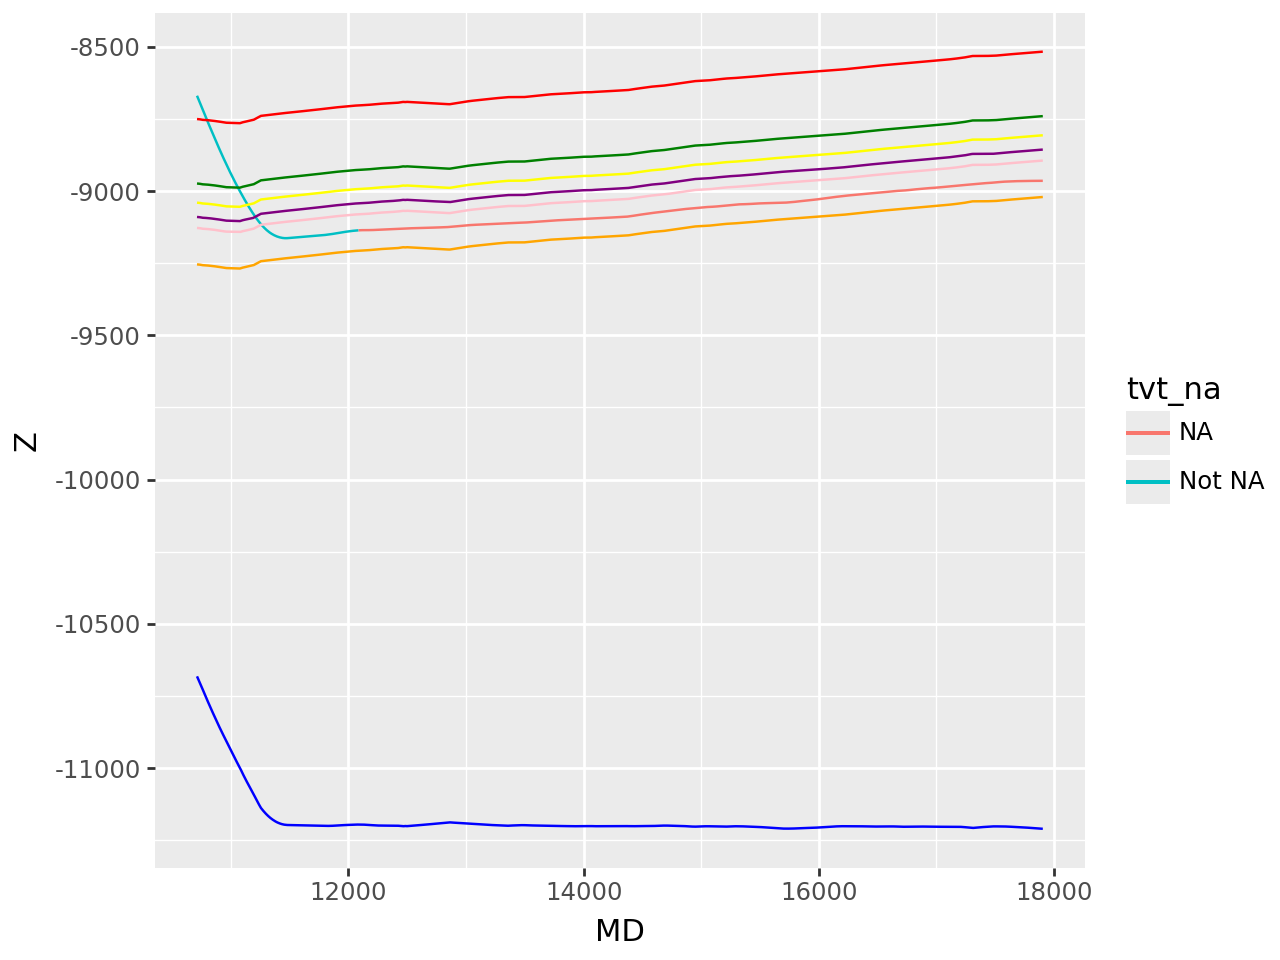

In [6]:
(
    df_h.assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    >> ggplot()
    + geom_line(aes(x='MD', y='Z', color='tvt_na')) 
    + geom_line(aes(x='MD',y='ANCC'), color='red')
    + geom_line(aes(x='MD',y='ASTNU'), color='green')
    + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='-1*TVT'), color = 'blue')
)

Analaysis below following from 1: trying to see if TVT follows similar shape as the MD for other wells too.

In [7]:
import random

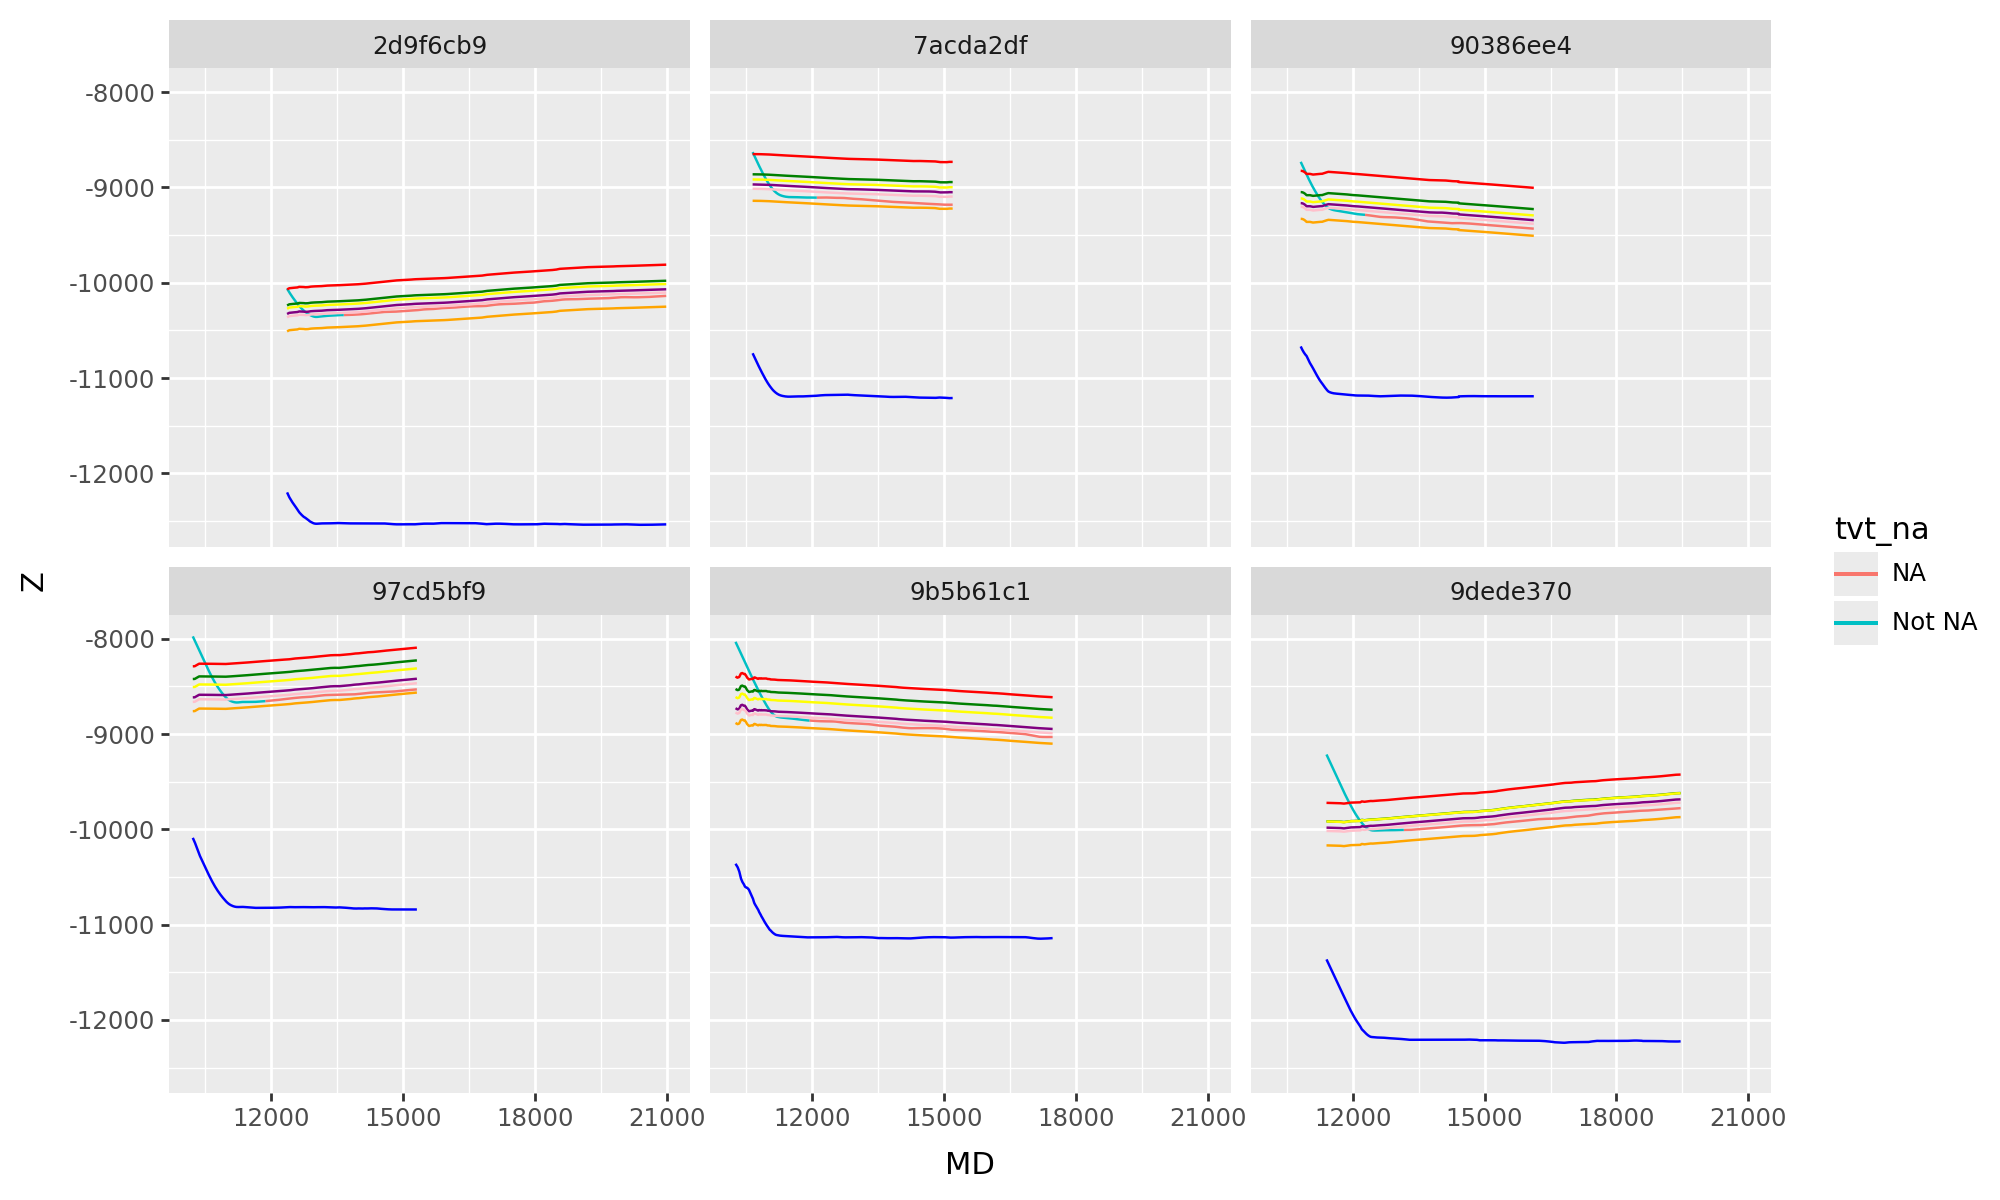

In [8]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .query("WELLNAME in @random_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    >> ggplot()
    + geom_line(aes(x='MD', y='Z', color='tvt_na')) 
    + geom_line(aes(x='MD',y='ANCC'), color='red')
    + geom_line(aes(x='MD',y='ASTNU'), color='green')
    + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='-1*TVT'), color = 'blue')
    + facet_wrap("WELLNAME")
    + theme(figure_size=(10, 6))
)

2. what is the relation between TVT and MD?

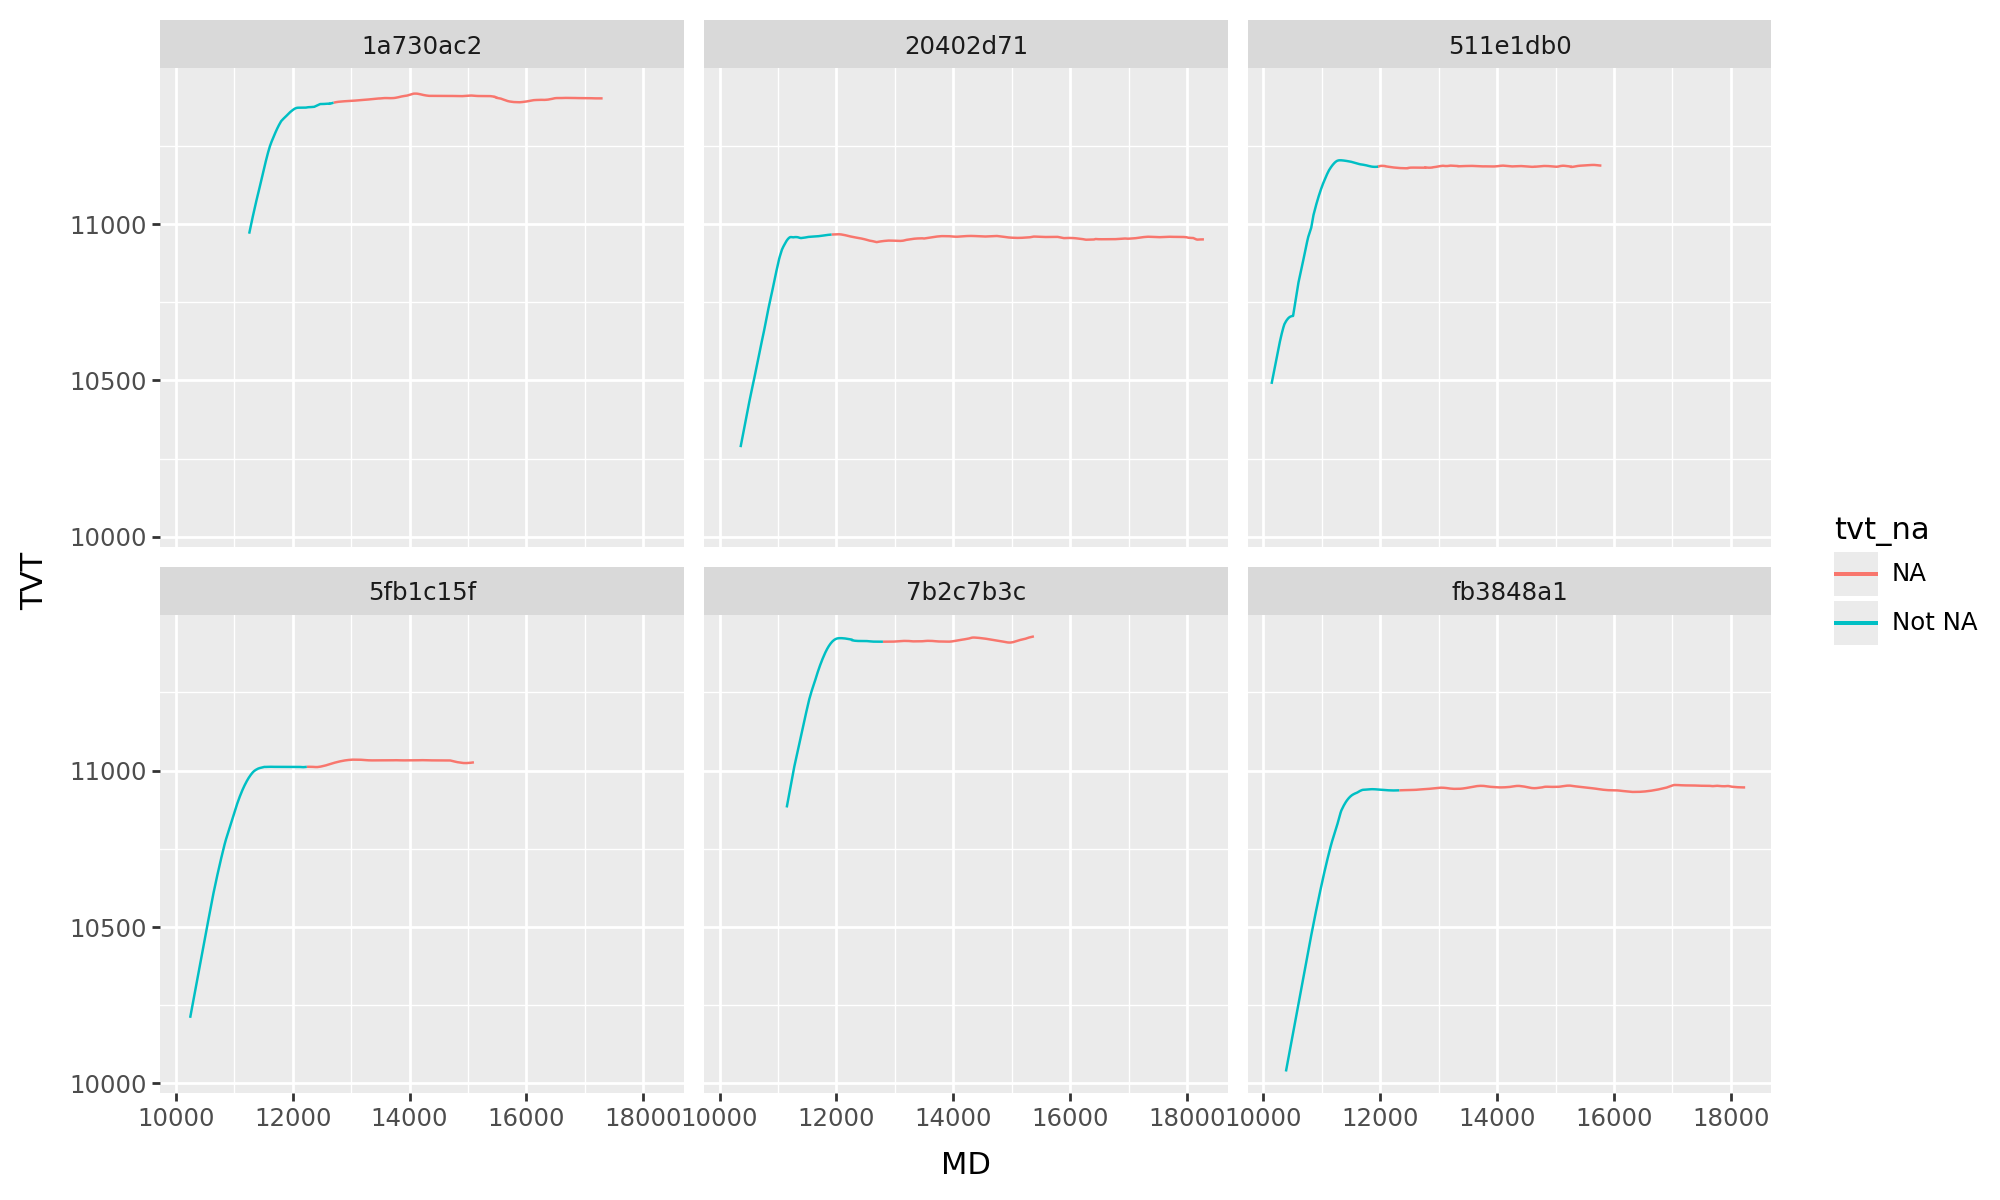

In [9]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .query("WELLNAME in @random_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    >> ggplot()
    # + geom_line(aes(x='MD', y='Z', color='tvt_na')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='TVT',color='tvt_na'))
    # + geom_line(aes(x='MD',y='pred'))
    + facet_wrap("WELLNAME")
    + theme(figure_size=(10, 6))
)

Follow from 2 where the start point begins..just follow of by extending with a straight line.

c:\Users\wishbertm\Documents\Personal\Learning\rogii-wellbore-geology-prediction\ROGII---Wellbore-Geology-Prediction\.pixi\envs\default\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 4570 rows containing missing values.


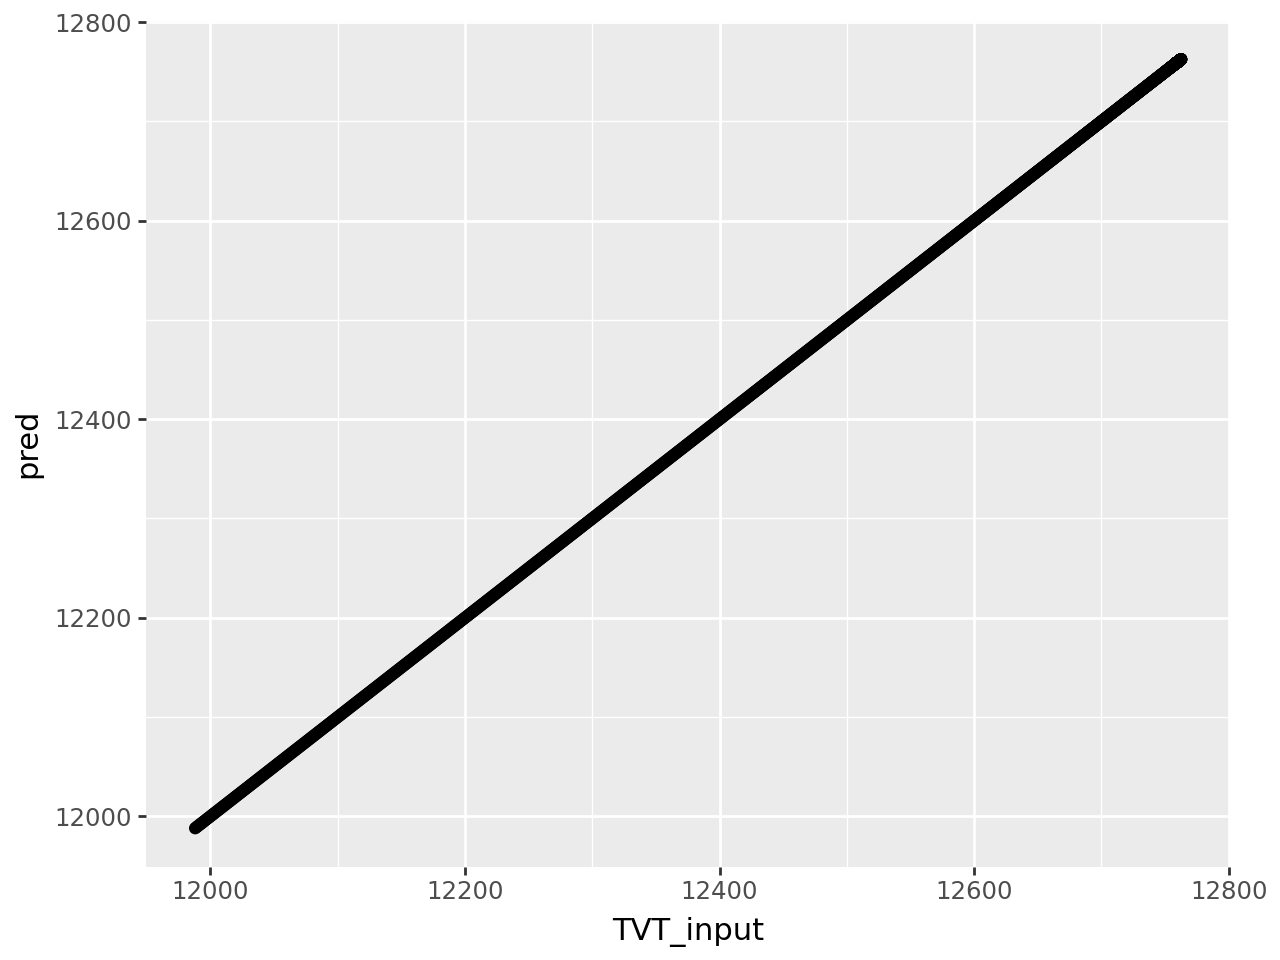

In [10]:
(
    horizontal_dataframe
    .query("WELLNAME == 'ffefef30'")
    .assign(pred = lambda col: col.TVT_input.ffill())
    >>
    ggplot(aes(x='TVT_input',y='pred'))
    + geom_point()
)

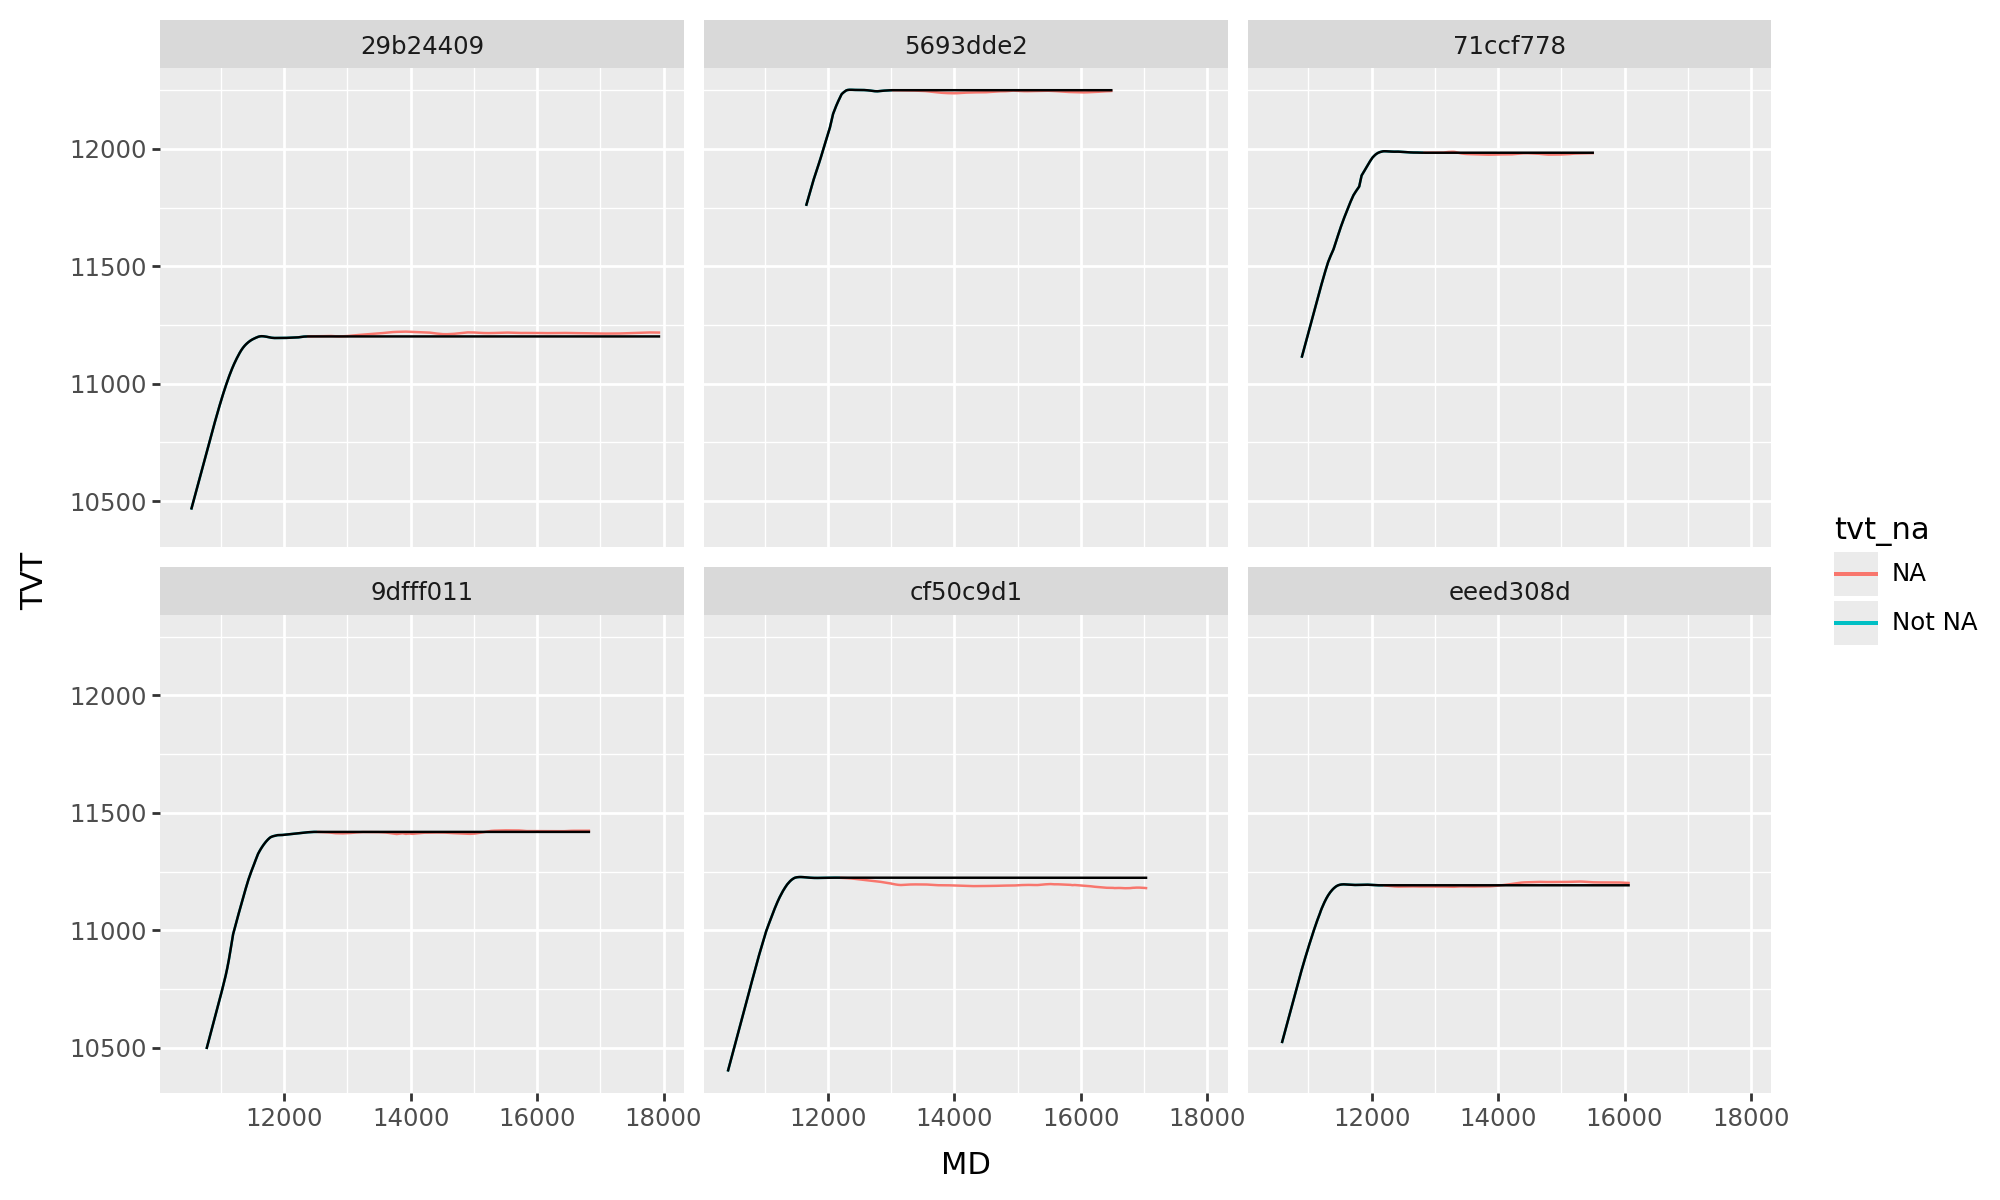

In [11]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .query("WELLNAME in @random_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    >> ggplot()
    # + geom_line(aes(x='MD', y='Z', color='tvt_na')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='TVT',color='tvt_na'))
    + geom_line(aes(x='MD',y='pred'))
    + facet_wrap("WELLNAME")
    + theme(figure_size=(10, 6))
)

Error analysis on the simple extension

In [12]:
highest_error_wells = (
    horizontal_dataframe
    # .query("WELLNAME in @random_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    .assign(abs_error = lambda col: abs(col.TVT-col.pred))
    .query("tvt_na=='NA'")
    .groupby('WELLNAME', as_index=False)
    .agg(
        cnt = ('MD','count'),
        avg_abs_error = ('abs_error','mean')
    )
    .sort_values('avg_abs_error',ascending=False)
).head(20)['WELLNAME'].tolist()

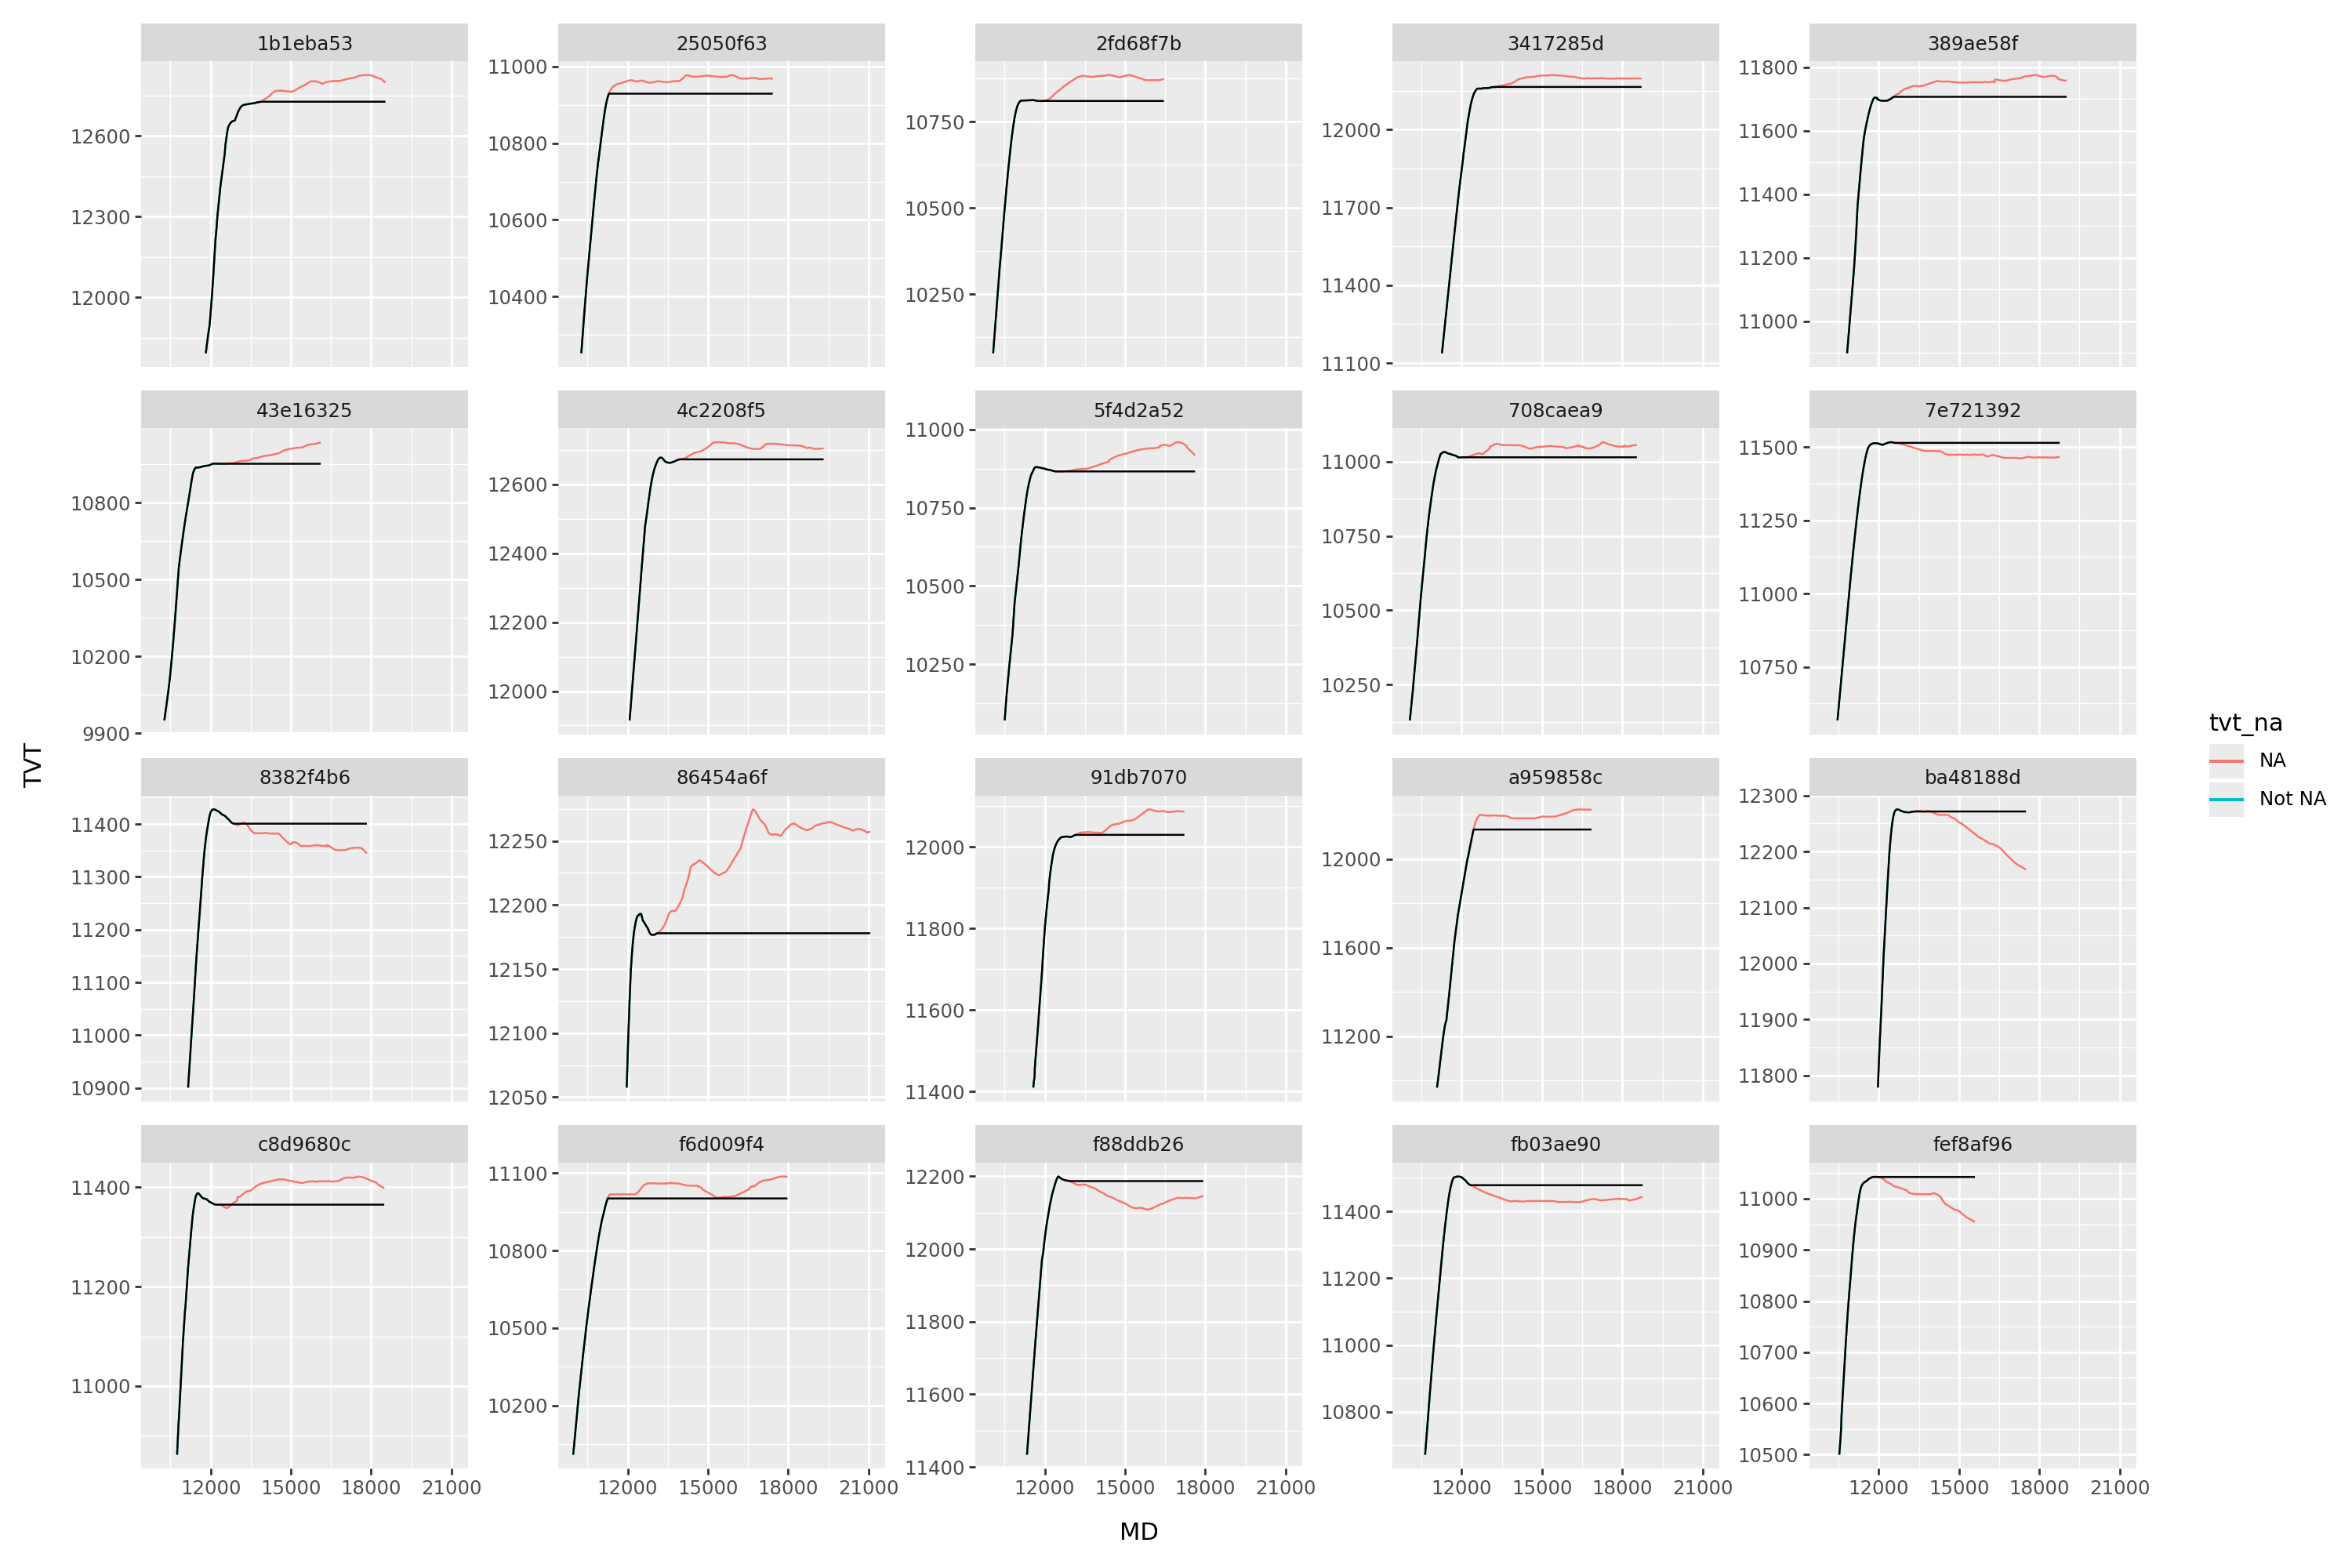

In [73]:
(
    horizontal_dataframe
    .query("WELLNAME in @highest_error_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    >> ggplot()
    # + geom_line(aes(x='MD', y='Z', color='tvt_na')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='TVT',color='tvt_na'))
    + geom_line(aes(x='MD',y='pred'))
    + facet_wrap("WELLNAME", scales='free_y')
    + theme(figure_size=(15, 10))
)

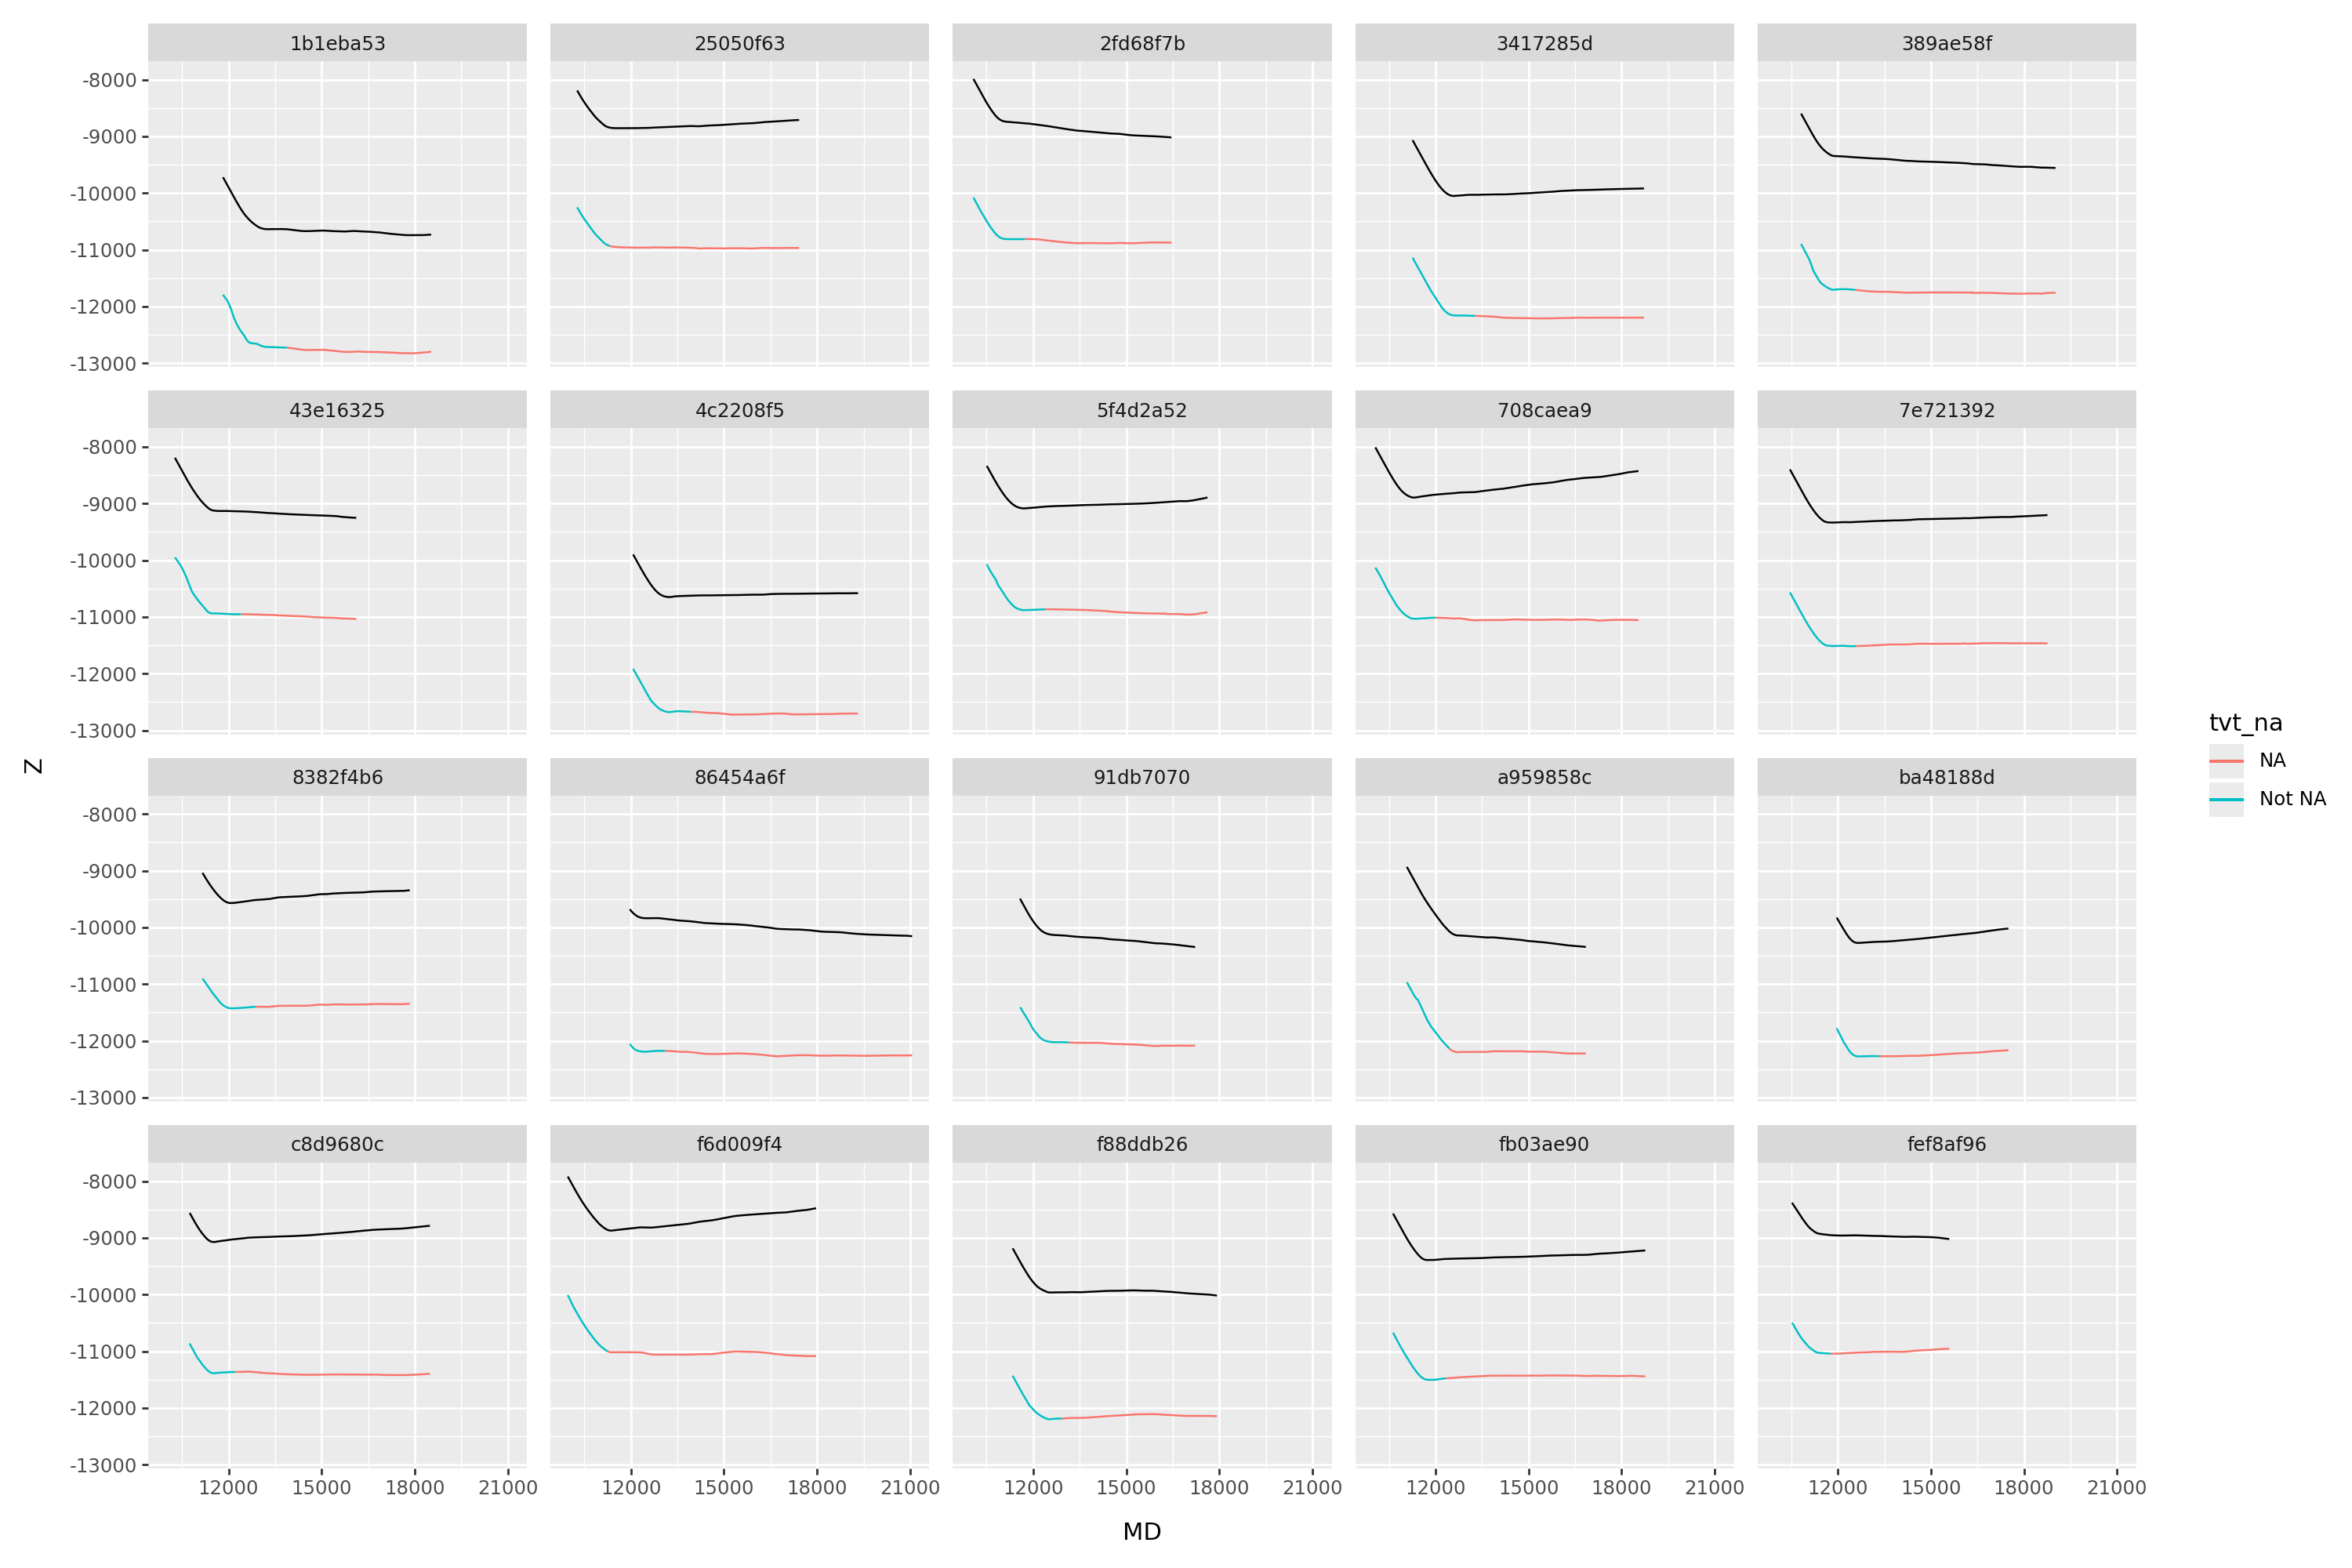

In [14]:
(
    horizontal_dataframe
    .query("WELLNAME in @highest_error_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    >> ggplot()
    + geom_line(aes(x='MD', y='Z')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='-1*TVT',color='tvt_na'))
    + facet_wrap("WELLNAME")
    + theme(figure_size=(15, 10))
)

In [15]:
total_tvt_z = (
    horizontal_dataframe
    .query("WELLNAME in @highest_error_wells")
    .groupby("WELLNAME", as_index=False)
    .agg(
        total_tvt = ('TVT','sum'),
        total_z = ('Z','sum')
    )
)

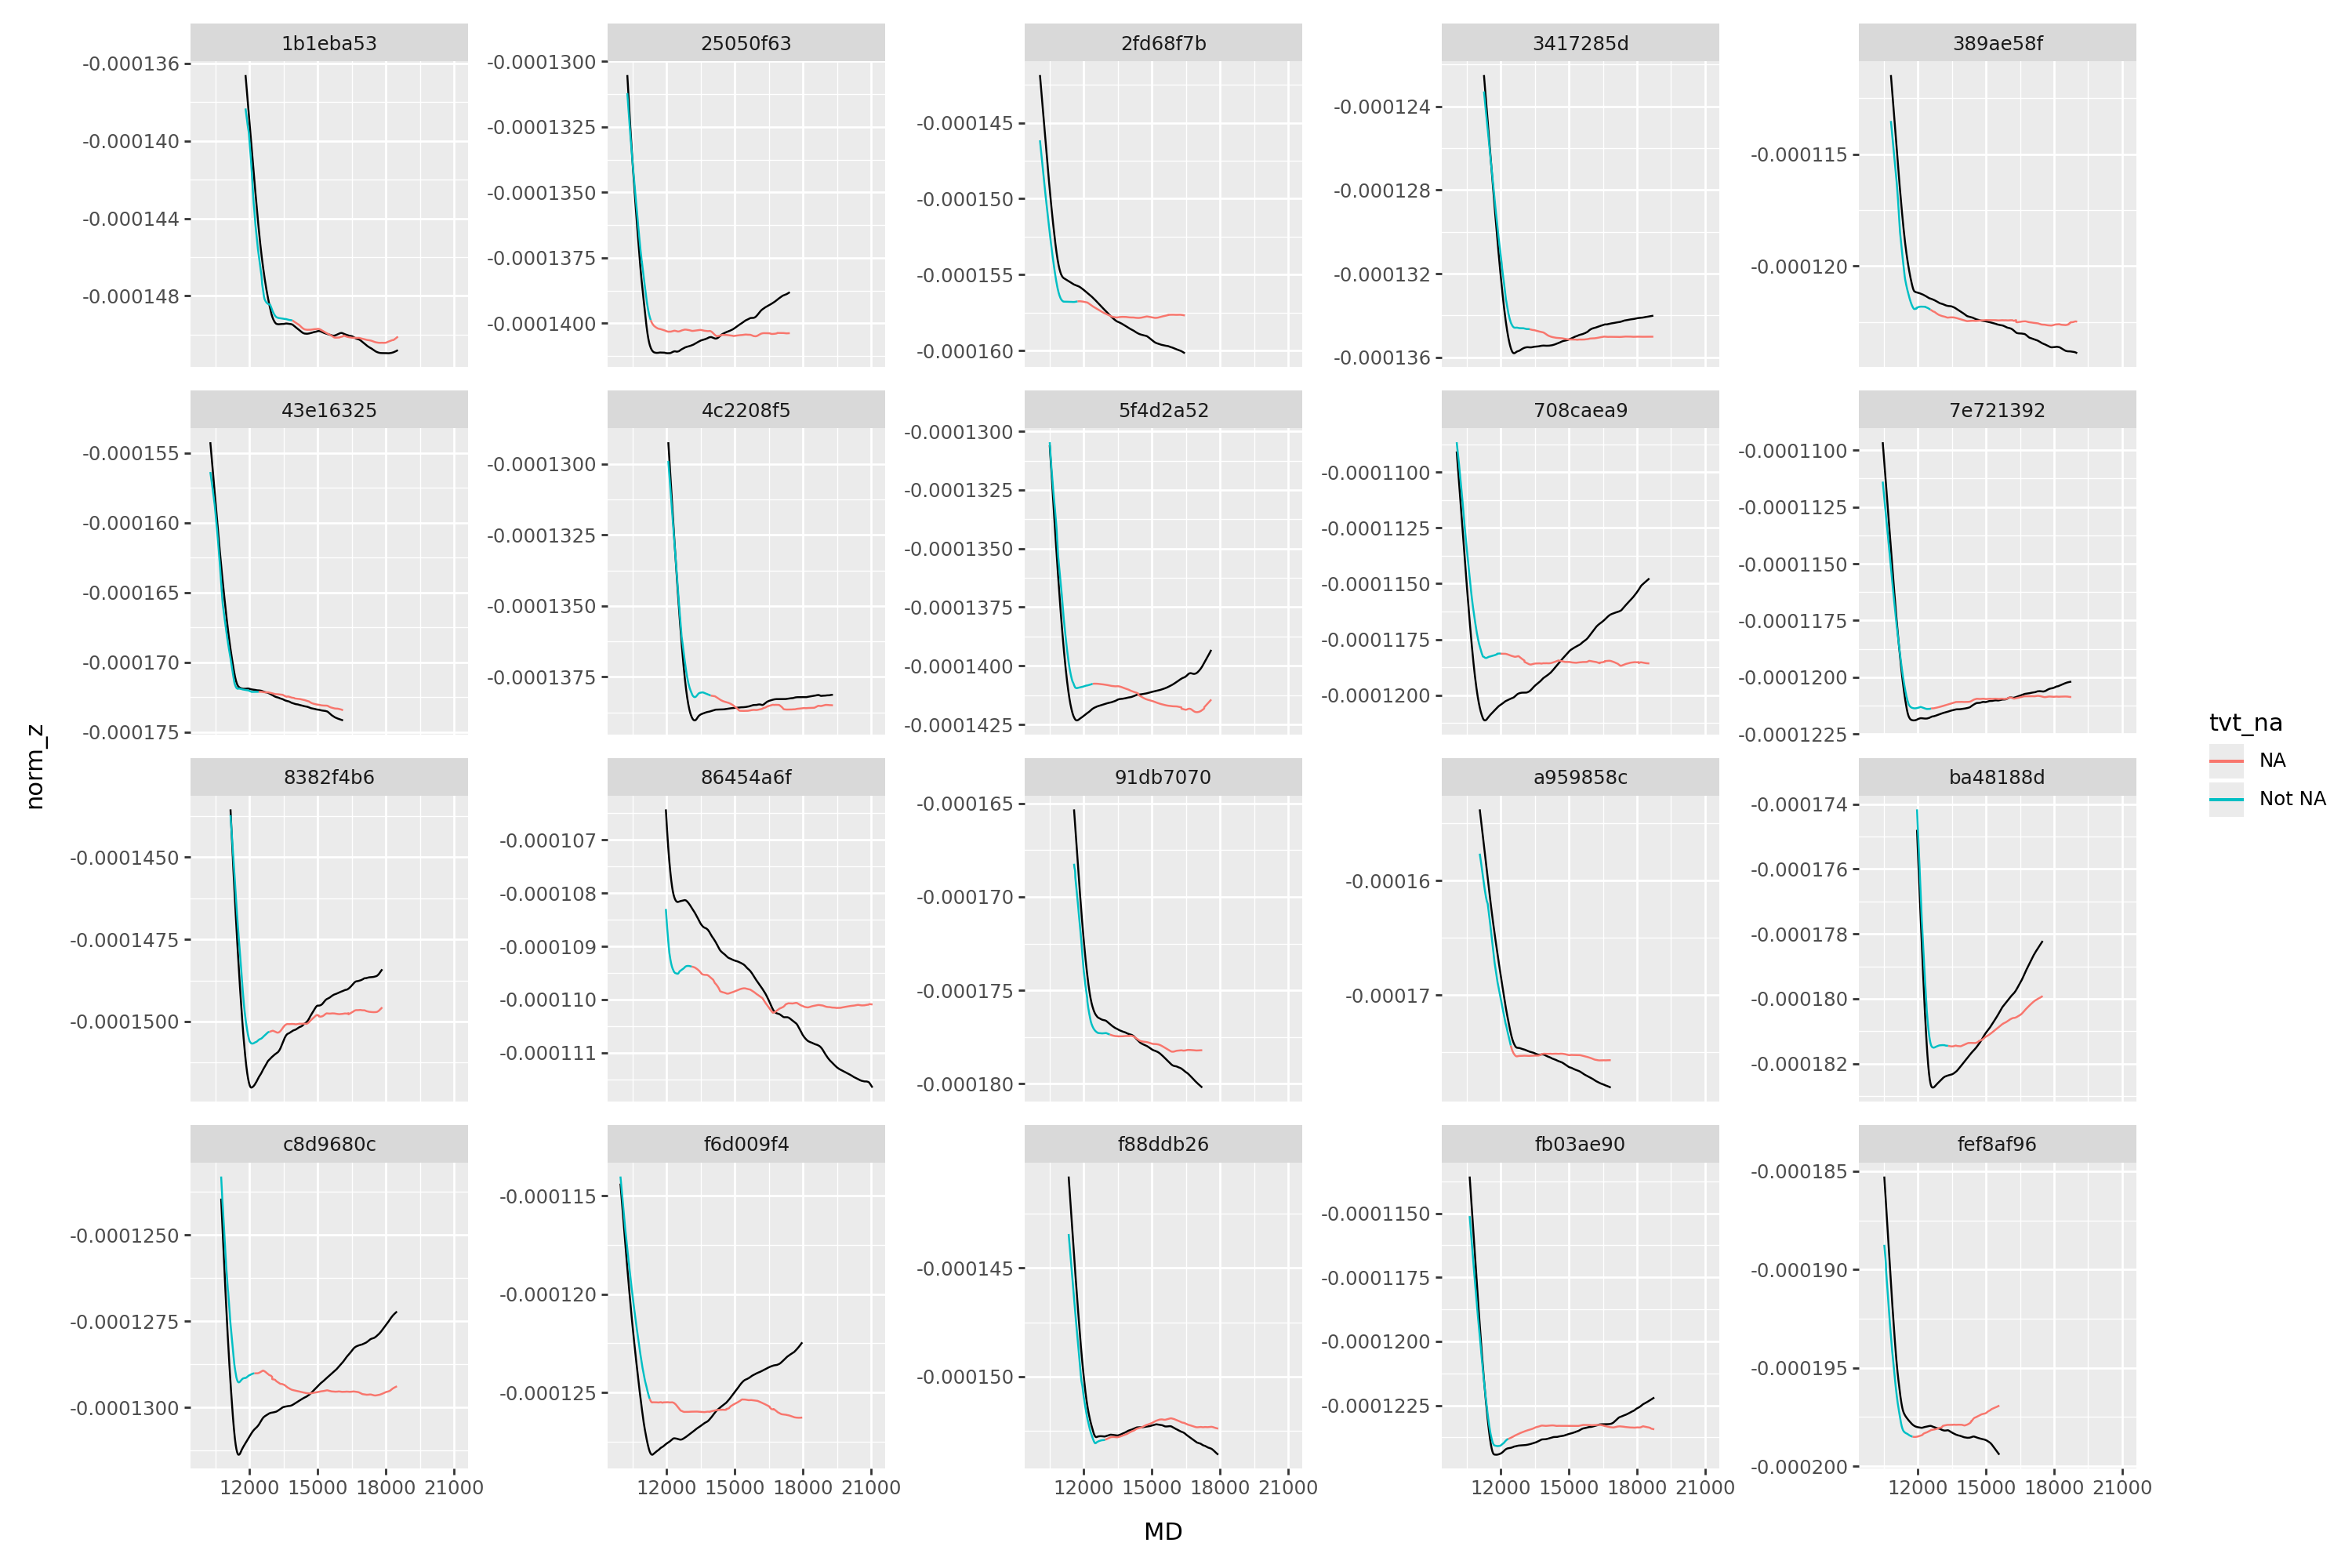

In [74]:
(
    horizontal_dataframe
    .query("WELLNAME in @highest_error_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .merge(total_tvt_z, on = ['WELLNAME'])
    .assign(
        norm_tvt = lambda col: col.TVT/col.total_tvt,
        norm_z = lambda col: -1*col.Z/col.total_z
    )
    >> ggplot()
    + geom_line(aes(x='MD', y='norm_z')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='-1*norm_tvt',color='tvt_na'))
    + facet_wrap("WELLNAME", scales='free_y')
    + theme(figure_size=(15, 10))
)

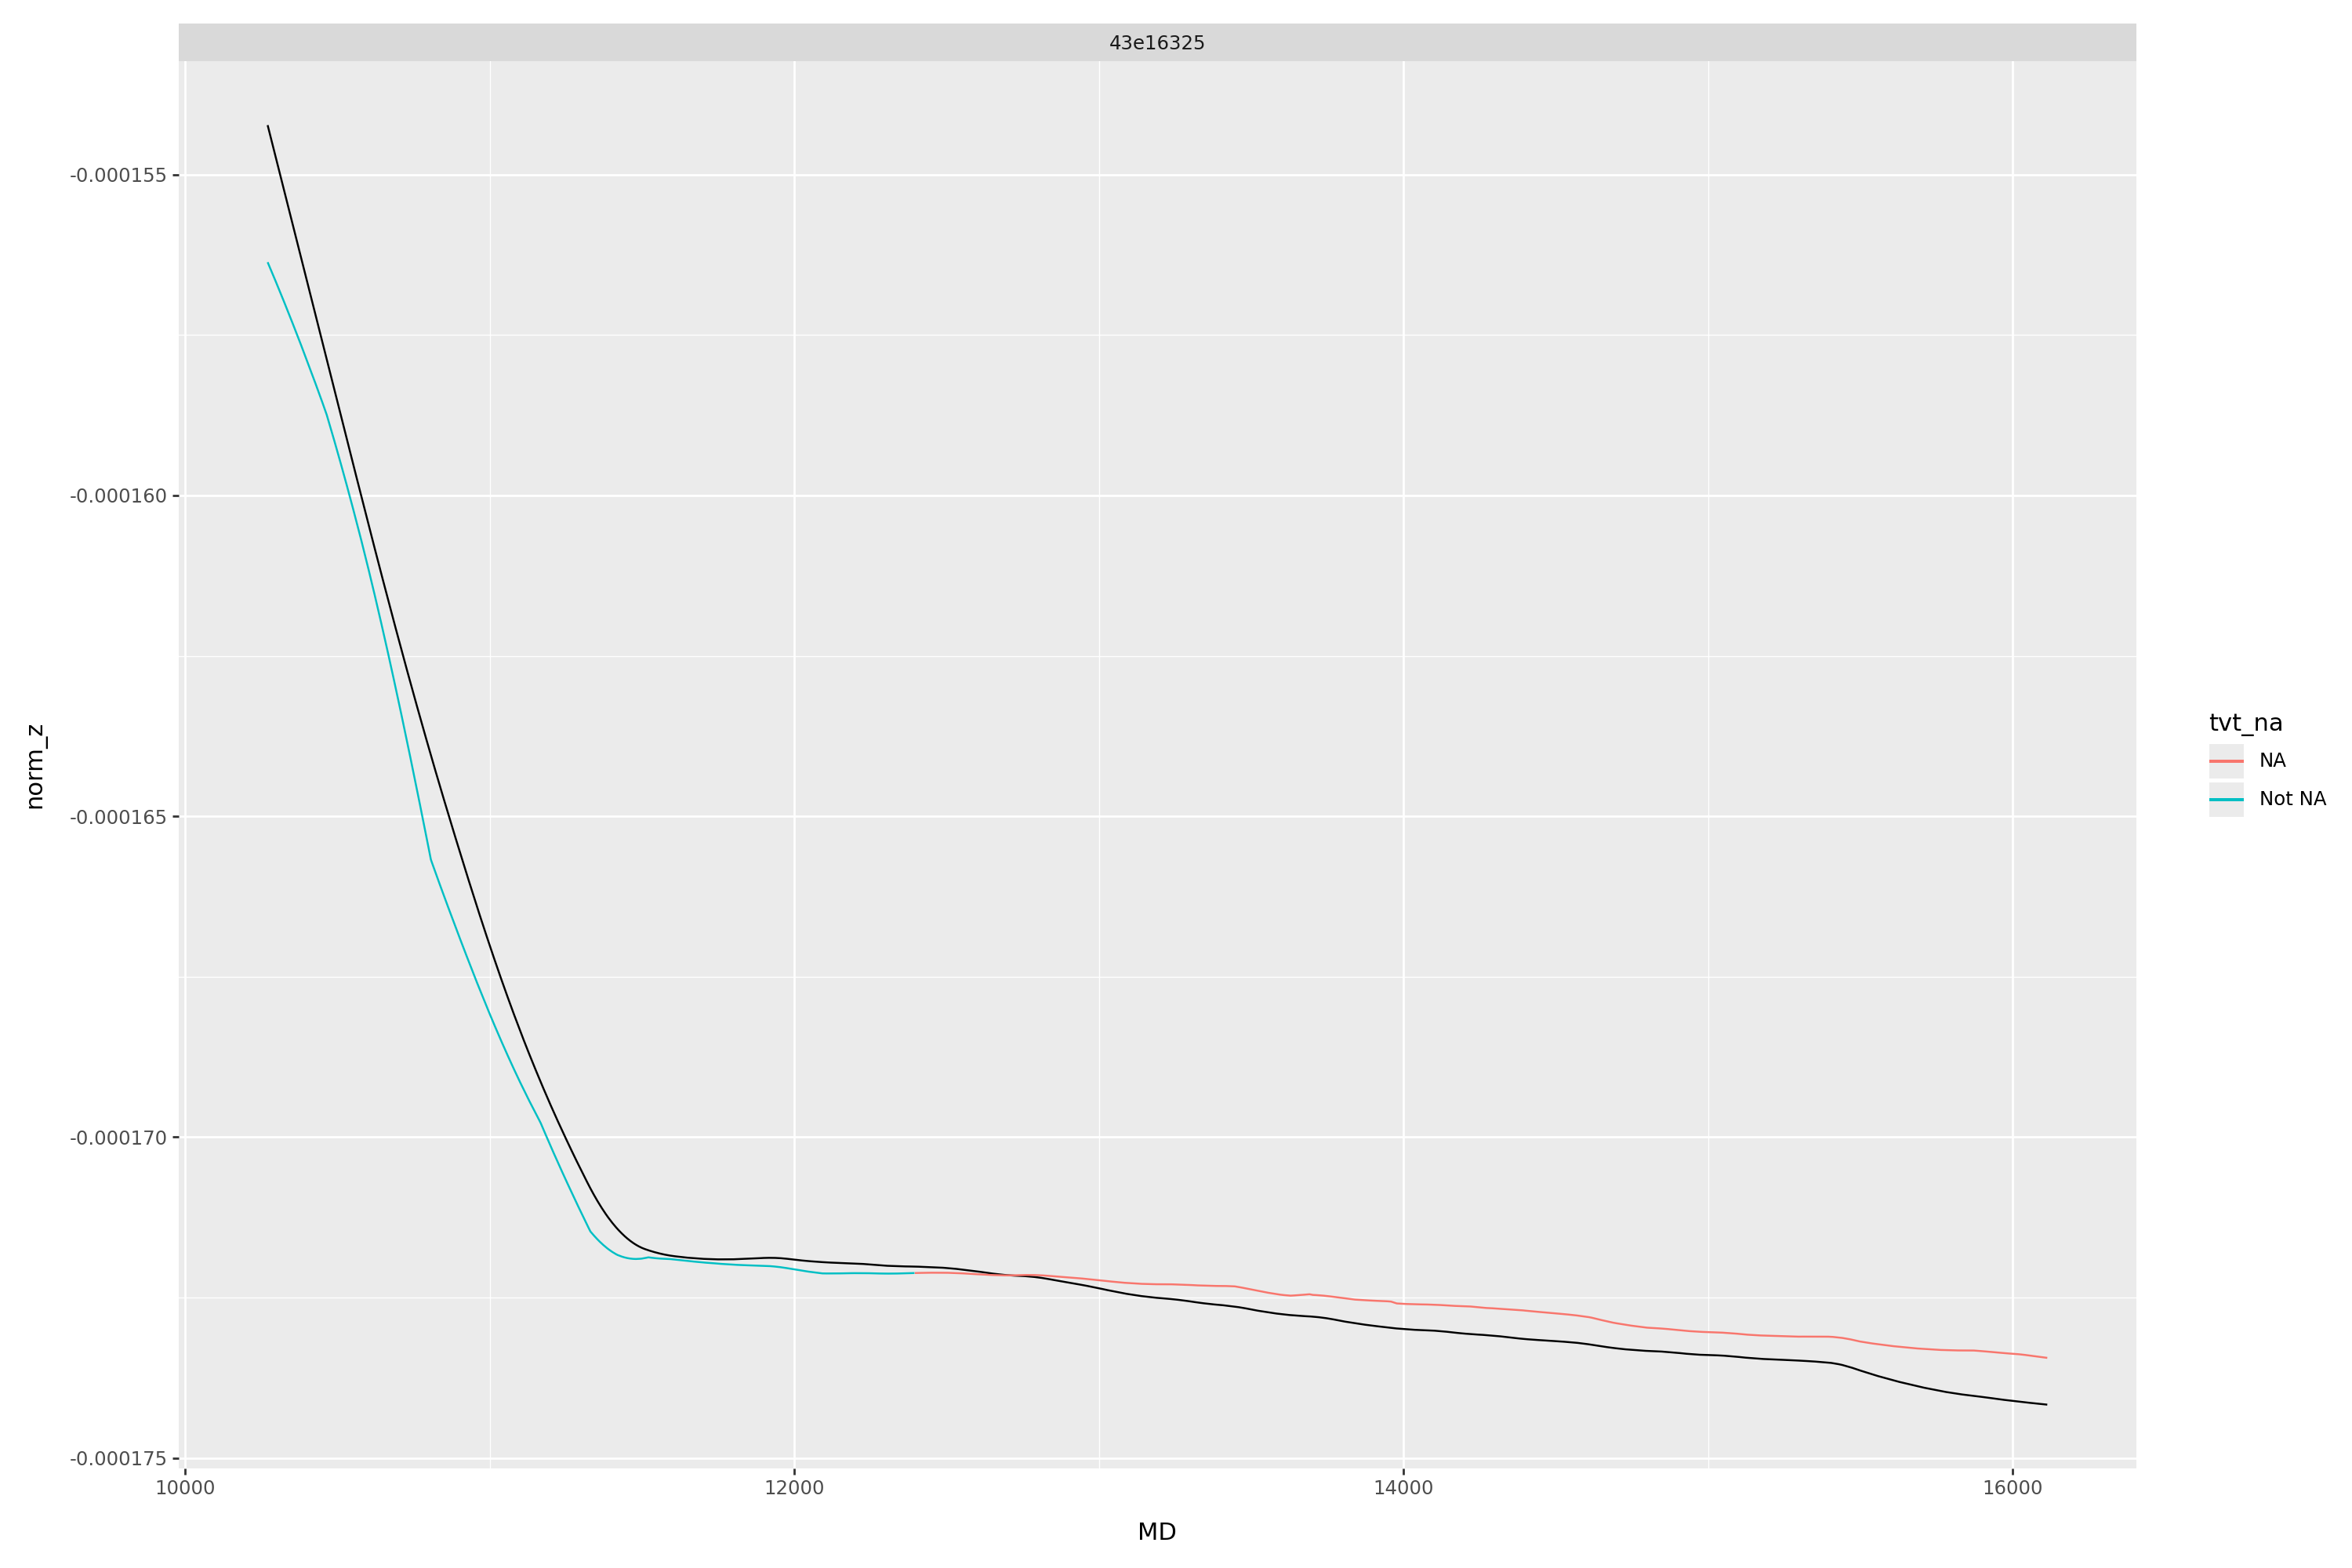

In [18]:
(
    horizontal_dataframe
    # .query("WELLNAME =='f6d009f4'")
    .query("WELLNAME == '43e16325'")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .merge(total_tvt_z, on = ['WELLNAME'])
    .assign(
        norm_tvt = lambda col: col.TVT/col.total_tvt,
        norm_z = lambda col: -1*col.Z/col.total_z
    )
    >> ggplot()
    + geom_line(aes(x='MD', y='norm_z')) 
    # + geom_line(aes(x='MD',y='ANCC'), color='red')
    # + geom_line(aes(x='MD',y='ASTNU'), color='green')
    # + geom_line(aes(x='MD',y='ASTNL'), color='yellow')
    # + geom_line(aes(x='MD',y='EGFDU'), color='purple')
    # + geom_line(aes(x='MD',y='EGFDL'), color='pink')
    # + geom_line(aes(x='MD',y='BUDA'), color='orange')
    + geom_line(aes(x='MD',y='-1*norm_tvt',color='tvt_na'))
    + facet_wrap("WELLNAME")
    + theme(figure_size=(15, 10))
)

c:\Users\wishbertm\Documents\Personal\Learning\rogii-wellbore-geology-prediction\ROGII---Wellbore-Geology-Prediction\.pixi\envs\default\Lib\site-packages\plotnine\geoms\geom_path.py:100: PlotnineWarning: geom_path: Removed 3 rows containing missing values.


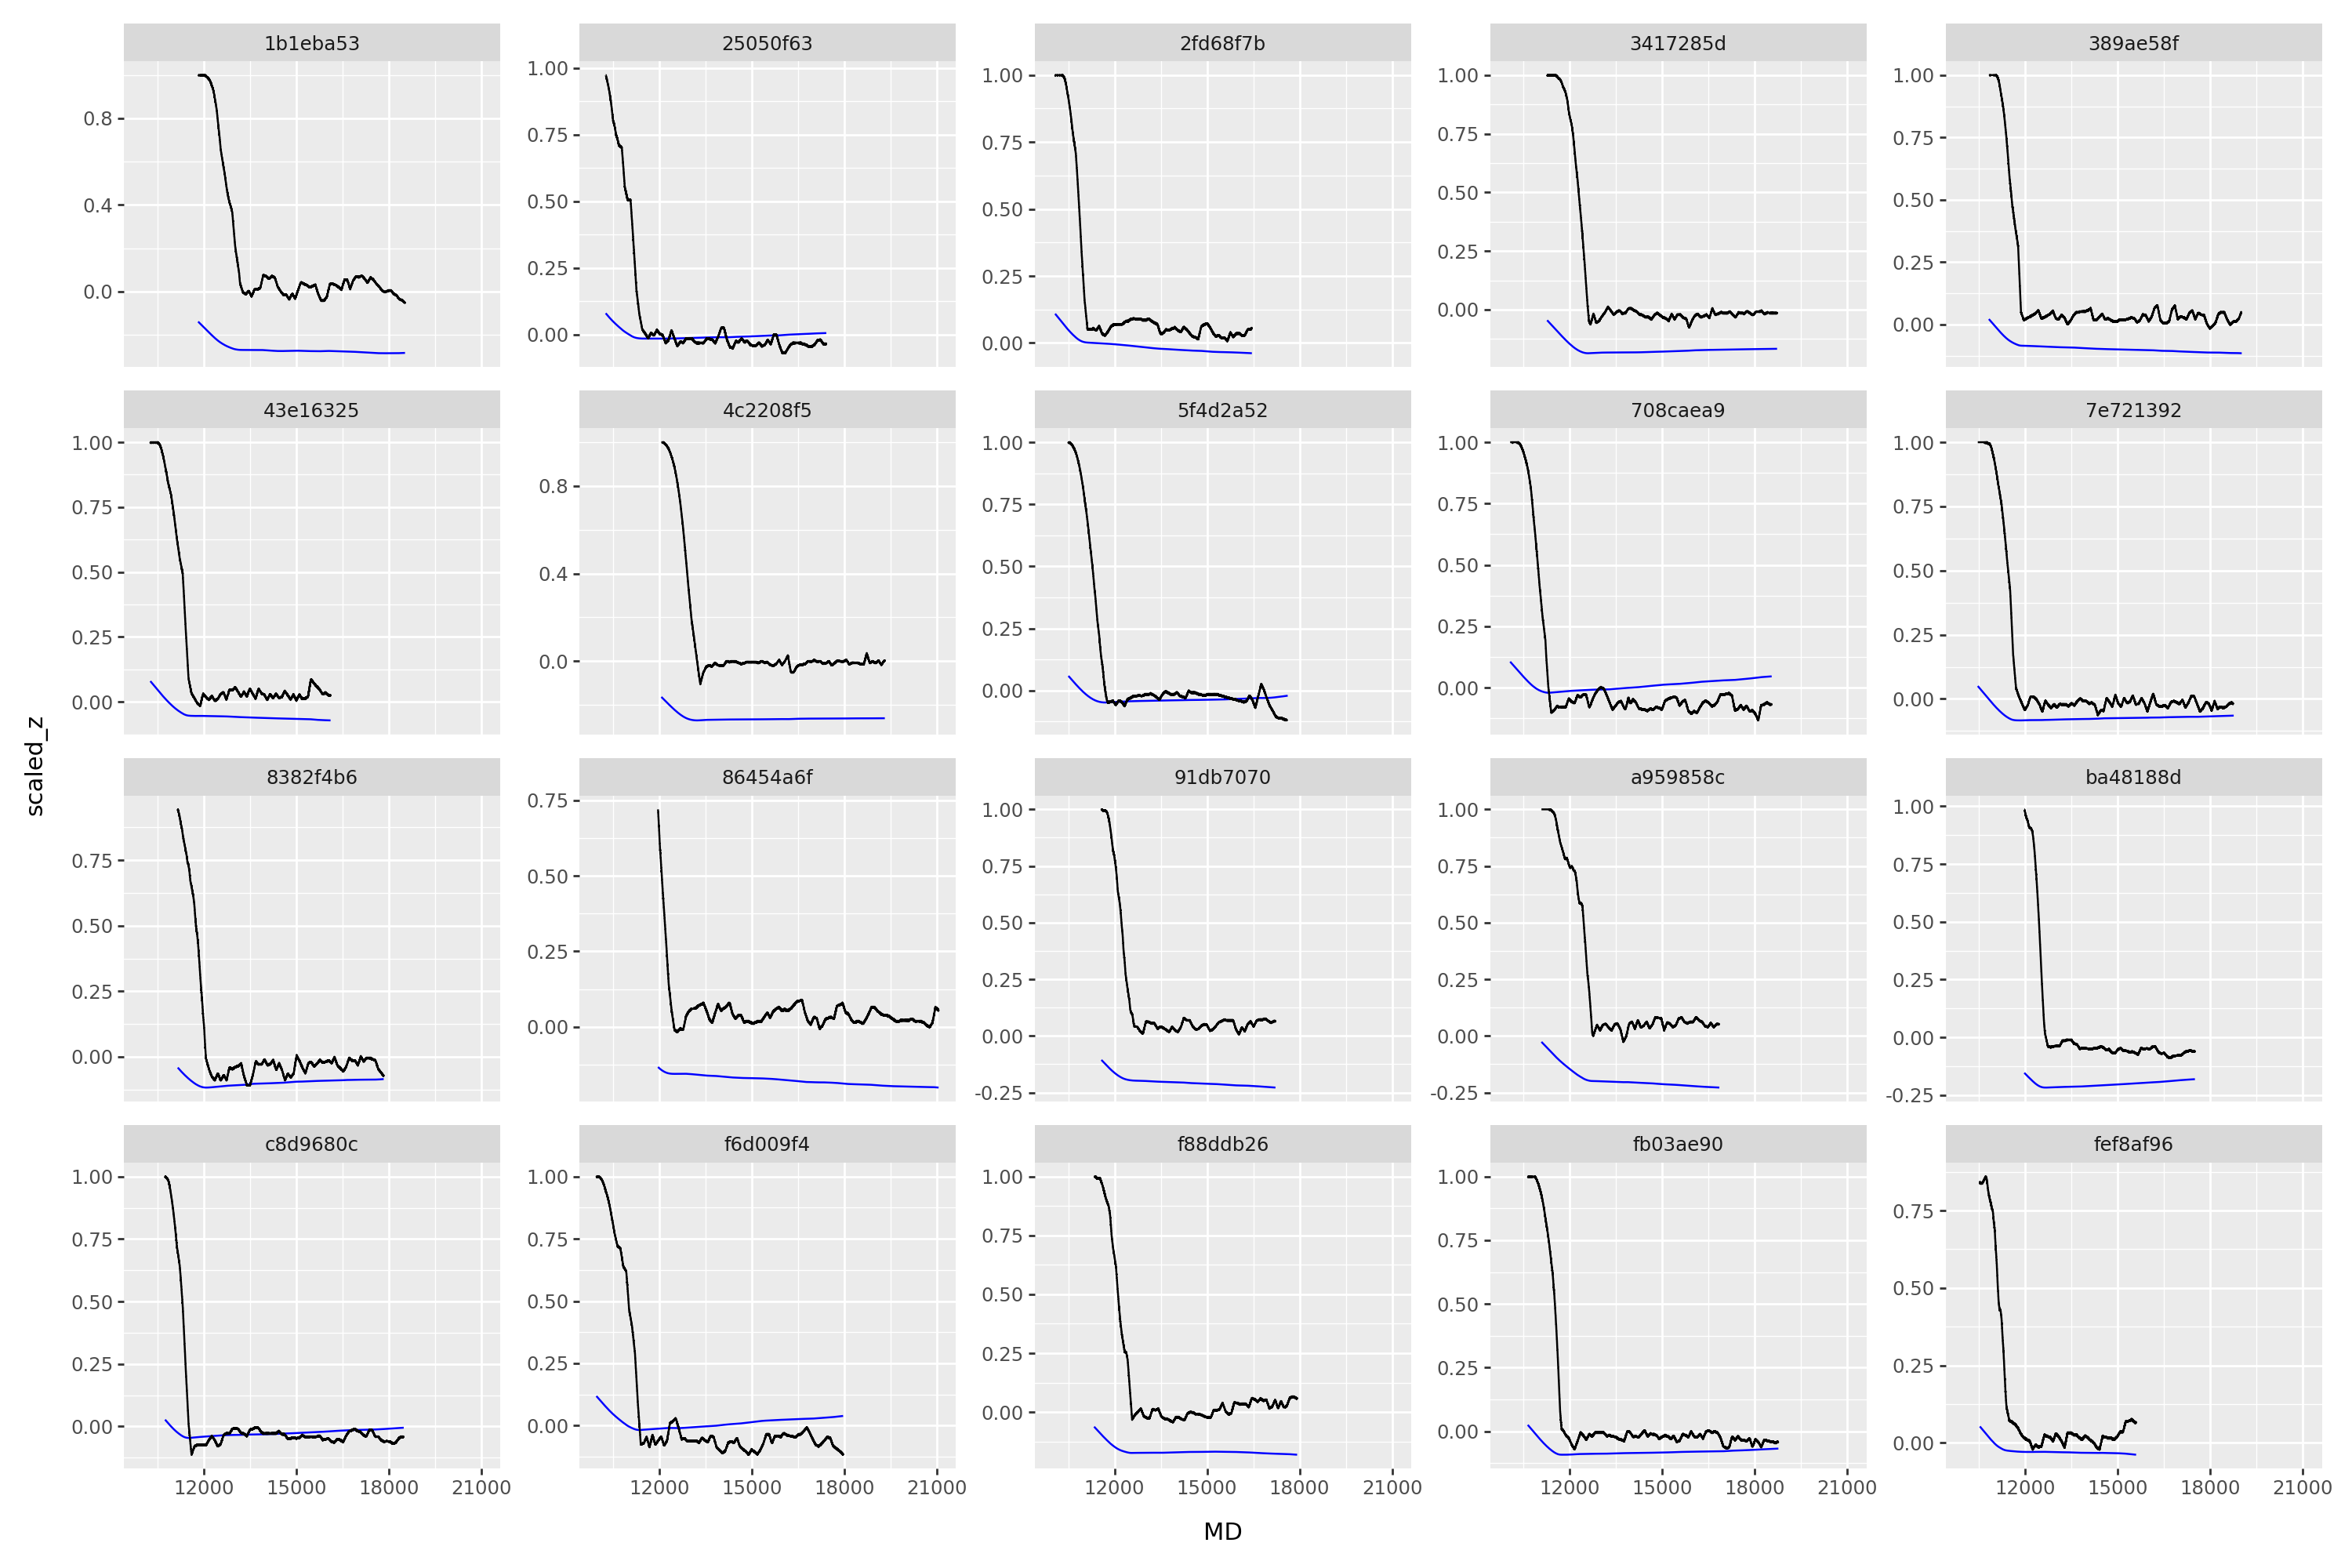

In [75]:
x_diff = -3
(
    horizontal_dataframe
    # .query("WELLNAME =='25050f63'")
    .query("WELLNAME in @highest_error_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .merge(total_tvt_z, on = ['WELLNAME'])
    .assign(
        norm_tvt = lambda col: col.TVT/col.total_tvt,
        norm_z = lambda col: -1*col.Z/col.total_z,
        z_change = lambda col: (col.Z - col.groupby("WELLNAME")['Z'].shift(x_diff))/(-1*x_diff),
        scaled_z = lambda col: col.Z/7000 + 1.25
    )
    # .query("shifted_z != shifted_z")
    >>
    ggplot()
    + geom_line(aes(x='MD',y='scaled_z'),color='blue')
    # + geom_line(aes(x='MD',y='shifted_z'), color='red')
    + geom_line(aes(x='MD',y='z_change'))
     + facet_wrap("WELLNAME", scales='free_y')
    + theme(figure_size=(15, 10))
)

Calculate slopes for all the wells and plot them using the random function I had at the start and see if the slope matches the charts

In [20]:
horizontal_dataframe.WELLNAME.unique().shape

(773,)

In [21]:
x_diff = -3
flat_z_part_cutoff = \
(
    horizontal_dataframe
    .assign(
        z_change_slope = lambda col: (col.Z - col.groupby("WELLNAME")['Z'].shift(x_diff))/(-1*x_diff)
    )
    .assign(
        is_close_to_zero = lambda col: abs(col.z_change_slope) <= 0.05,
        row_index = lambda col: col.index
    )
    .query("is_close_to_zero")
    .groupby("WELLNAME", as_index=False)
    .agg(
        min_index = ('row_index','min')
    )
    .assign(
        min_index = lambda col: col.min_index+10
    )
)

In [22]:
flat_z_part_cutoff.shape, horizontal_dataframe.WELLNAME.unique().shape

((773, 2), (773,))

c:\Users\wishbertm\Documents\Personal\Learning\rogii-wellbore-geology-prediction\ROGII---Wellbore-Geology-Prediction\.pixi\envs\default\Lib\site-packages\plotnine\geoms\geom_path.py:100: PlotnineWarning: geom_path: Removed 3 rows containing missing values.


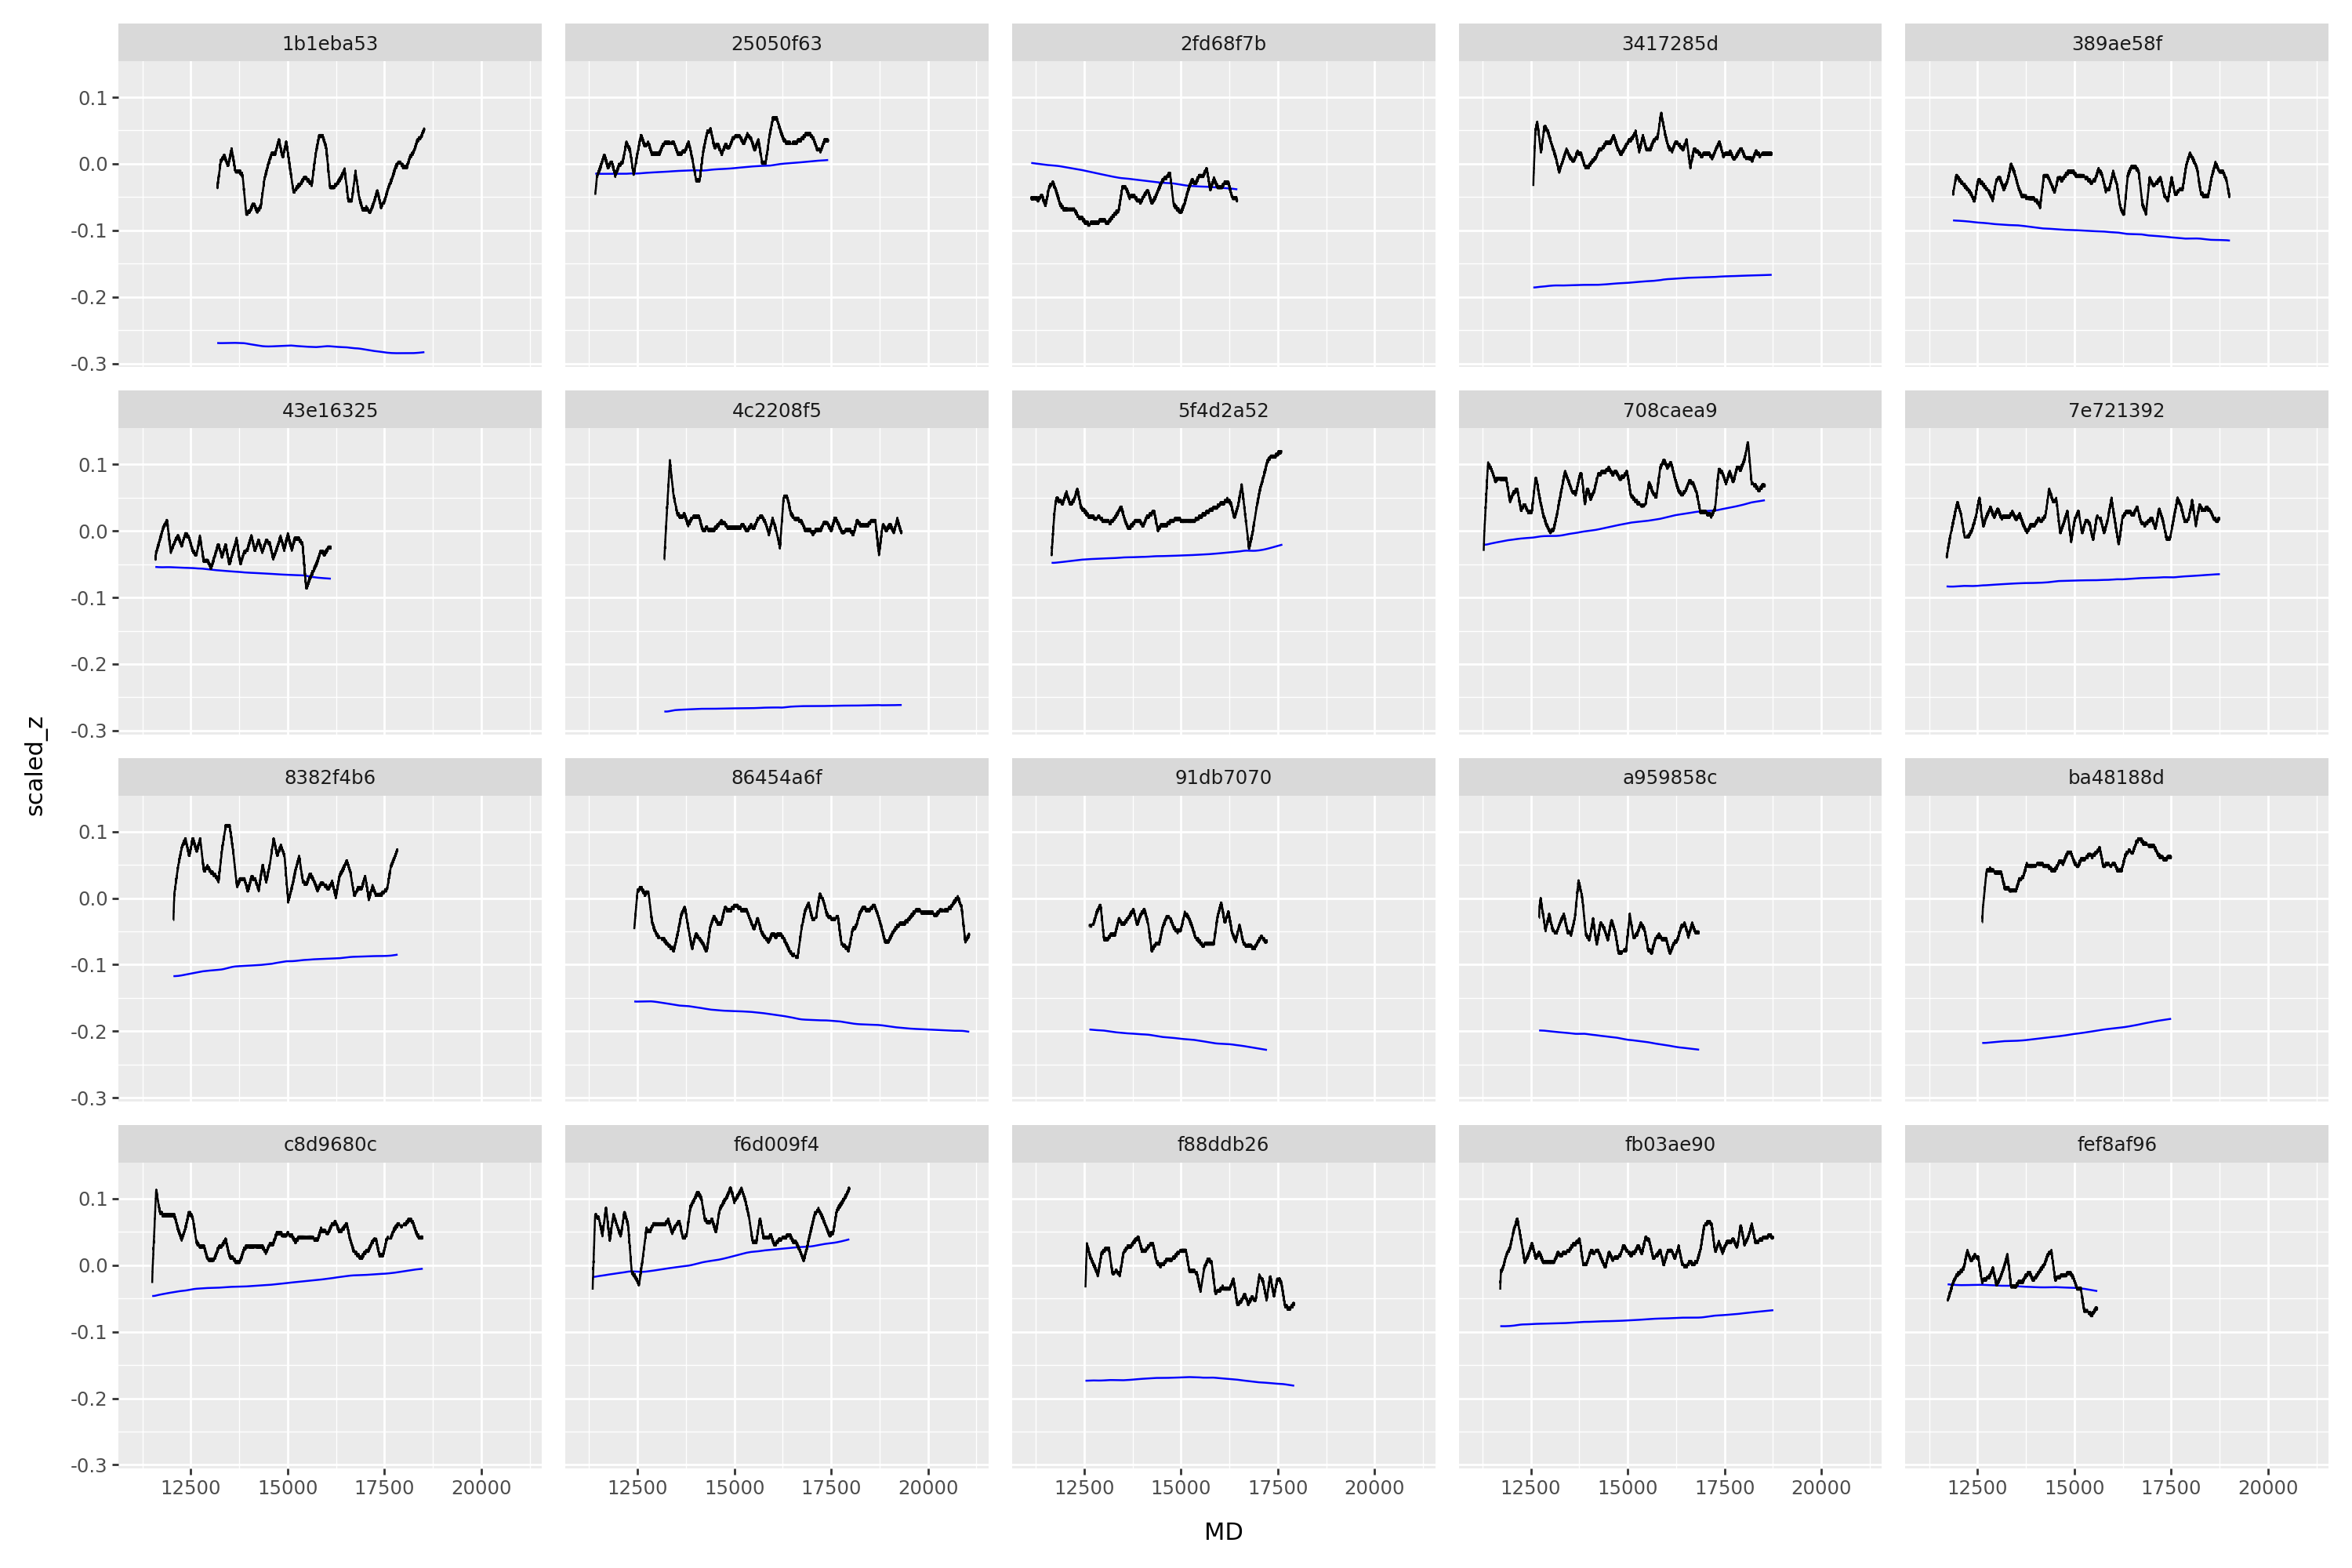

In [23]:
x_diff = -3
(
    horizontal_dataframe
    .assign(row_index =lambda col: col.index)
    .merge(flat_z_part_cutoff, on=['WELLNAME'], how='left')
    .query("WELLNAME in @highest_error_wells")
    # .query("WELLNAME == '1b1eba53'")
    # # .query("WELLNAME == '0dc5e64d'")
    .assign(
        z_change_slope = lambda col: (col.Z - col.groupby("WELLNAME")['Z'].shift(x_diff))/(1*x_diff),
        scaled_z = lambda col: col.Z/7000 + 1.25,
        # index_mask = lambda col: col.row_index>=col.min_index
    )
    .query("row_index >= min_index")
    >>
    ggplot()
    + geom_line(aes(x='MD',y='scaled_z'),color='blue')
    # + geom_line(aes(x='MD',y='shifted_z'), color='red')
    + geom_line(aes(x='MD',y='z_change_slope'))
    # + geom_line(aes(x="MD",y='Z'))
    + facet_wrap("WELLNAME")
    + theme(figure_size=(15, 10))
)

In [24]:
x_diff = -3
flat_z_part_slopes = (
    horizontal_dataframe
    .assign(row_index =lambda col: col.index)
    .merge(flat_z_part_cutoff, on=['WELLNAME'], how='left')
    .assign(
        z_change_slope = lambda col: (col.Z - col.groupby("WELLNAME")['Z'].shift(x_diff))/(1*x_diff)
    )
    .query("row_index >= min_index")
    .groupby("WELLNAME",as_index=False)
    .agg(
        avg_slope = ('z_change_slope','mean')
    )
)

** I have the slopes. Use them to make the charts flat then get the shape

In [25]:
y_intercept_locator = horizontal_dataframe[~horizontal_dataframe.TVT_input.isna()].assign(y_intercept_index=lambda col: col.index).groupby('WELLNAME',as_index=False).y_intercept_index.max()

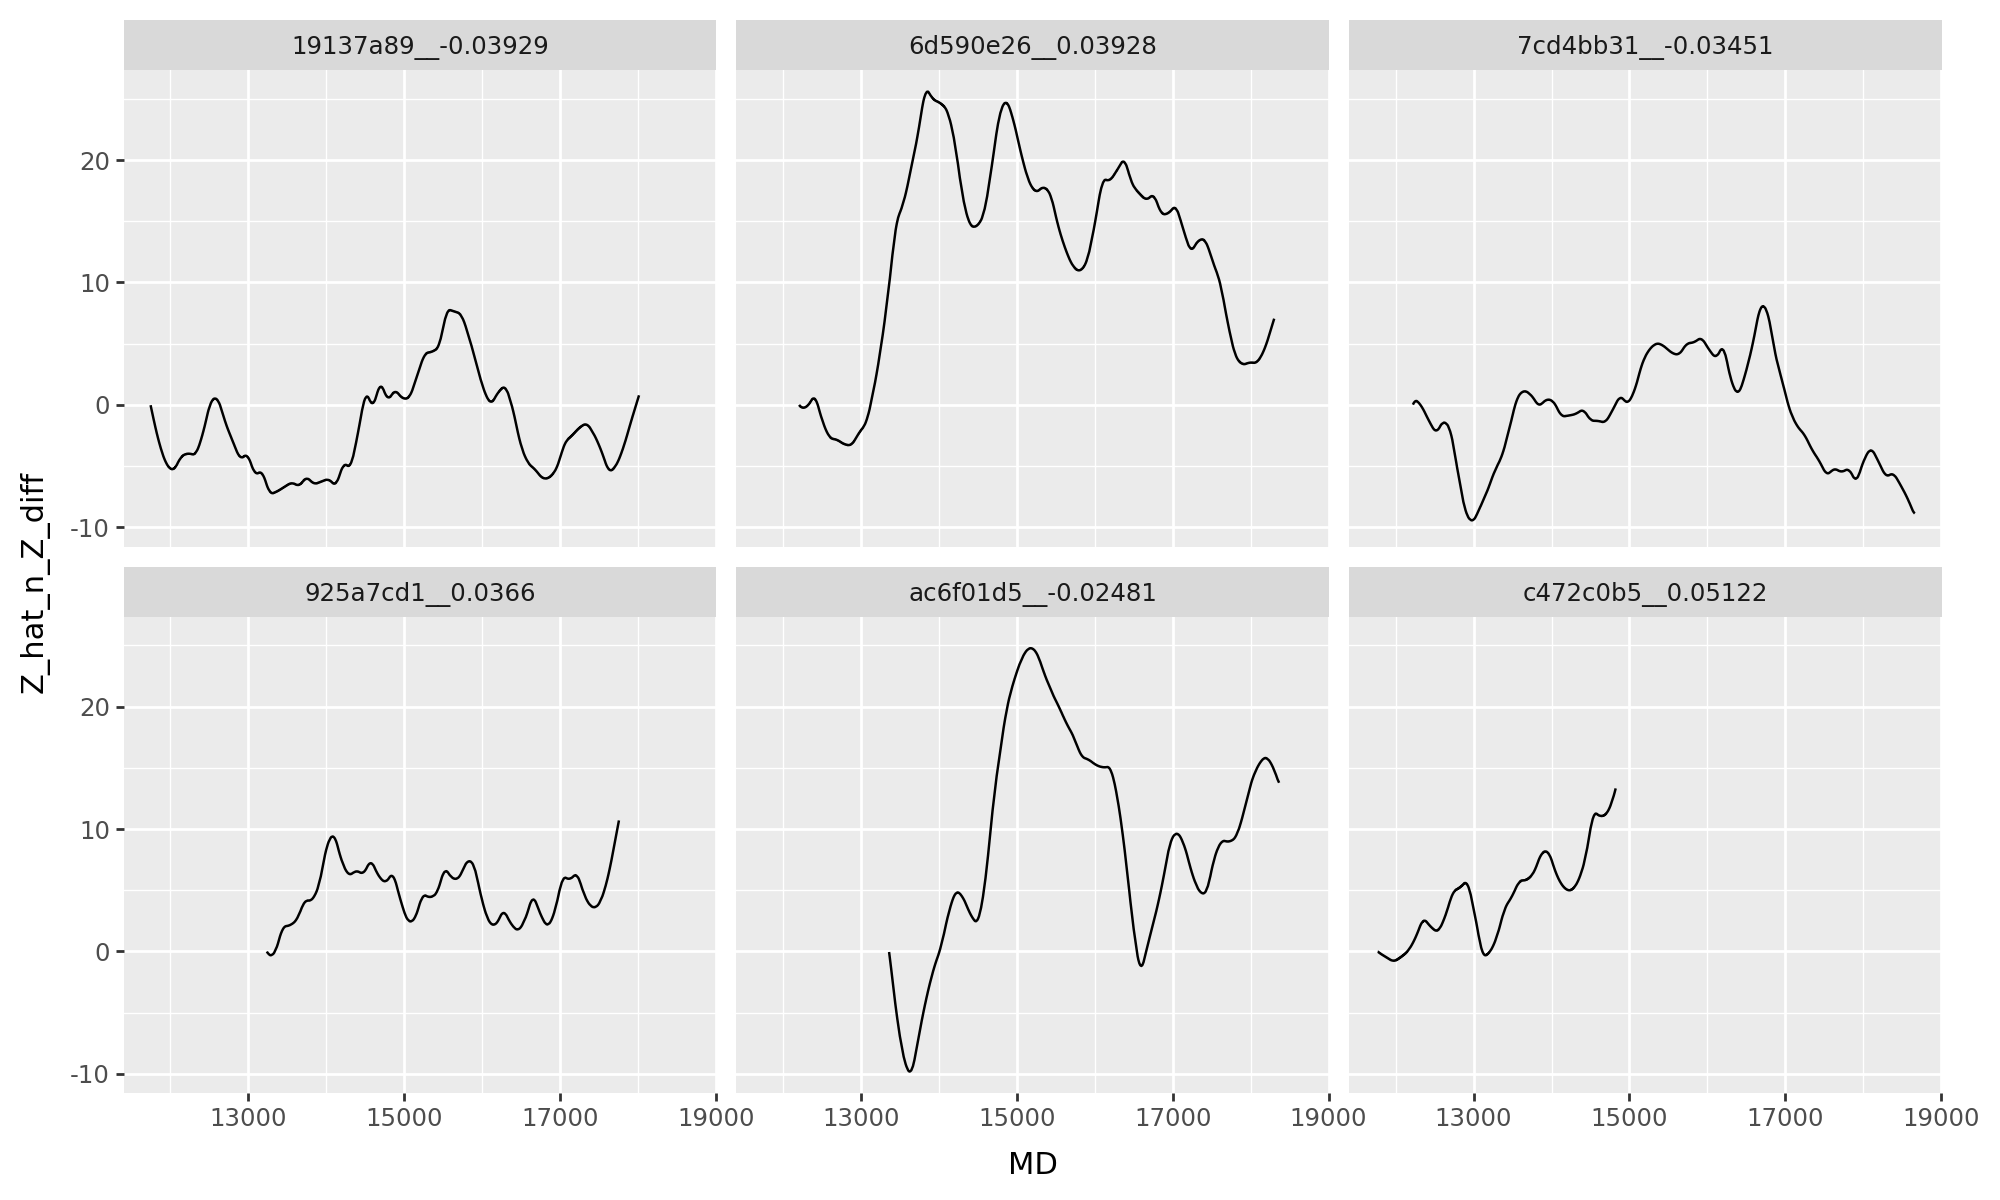

In [36]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .assign(indx = lambda col: col.index)
    .merge(flat_z_part_slopes, on=['WELLNAME'])
    .merge(y_intercept_locator, on=['WELLNAME'])
    .query("WELLNAME in @random_wells")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    .assign(
        well_slope = lambda col: col.WELLNAME+"__"+col.avg_slope.round(5).astype(str),
        y_intercept_value = lambda col: np.where(col.y_intercept_index==col.indx,col.Z,np.nan),
        MD_zero = lambda col: np.where(col.y_intercept_index==col.indx,col.MD,np.nan)
    )
    .assign(
        Z_hat = lambda col: (col.MD-col.MD_zero.ffill())*col.avg_slope + col.y_intercept_value.ffill()
    )
    .assign(
        Z_hat_n_Z_diff = lambda col: col.Z-col.Z_hat
    )
    # .query("WELLNAME=='ffefef30'")
    .query("tvt_na=='NA'")
    # .query("indx>=y_int_minus_5")
    >> ggplot()
    # + geom_line(aes(x='MD', y='Z')) 
    # + geom_line(aes(x='MD',y='Z_hat'))
    + geom_line(aes(x="MD",y='Z_hat_n_Z_diff'))
    + facet_wrap("well_slope")
    + theme(figure_size=(10, 6))
)
#5,092,255

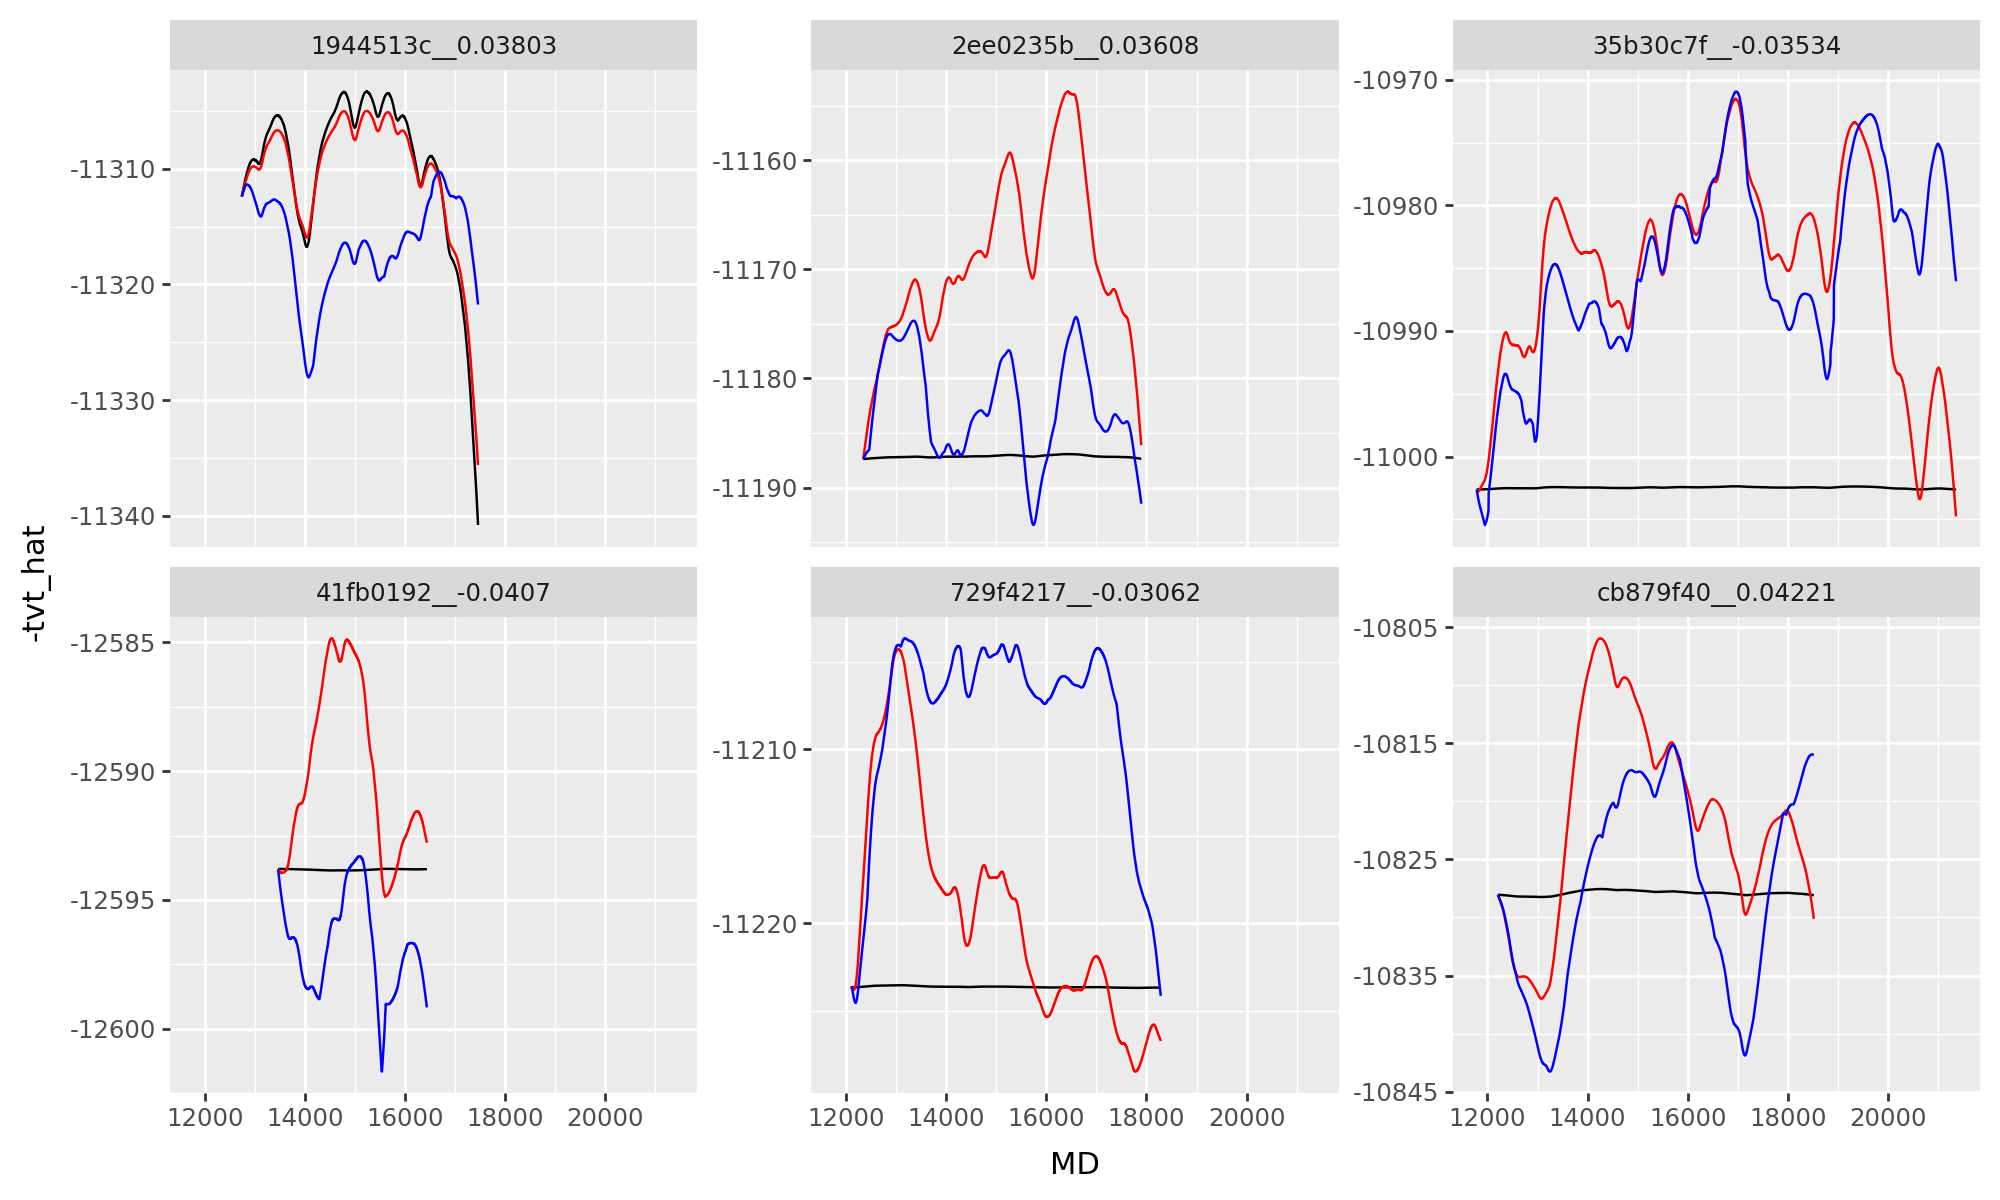

In [148]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .assign(indx = lambda col: col.index)
    .merge(flat_z_part_slopes, on=['WELLNAME'])
    .merge(y_intercept_locator, on=['WELLNAME'])
    .query("WELLNAME in @random_wells")
    # .query("WELLNAME=='30d75030'")
    # .query("WELLNAME=='a959858c'")
    # .query("WELLNAME=='4c2208f5'")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    .assign(
        well_slope = lambda col: col.WELLNAME+"__"+col.avg_slope.round(5).astype(str),
        y_intercept_value = lambda col: np.where(col.y_intercept_index==col.indx,col.Z,np.nan),
        MD_zero = lambda col: np.where(col.y_intercept_index==col.indx,col.MD,np.nan)
    )
    .assign(
        Z_hat = lambda col: (col.MD-col.MD_zero.ffill())*col.avg_slope + col.y_intercept_value.ffill()
    )
    .assign(
        Z_hat_n_Z_diff = lambda col: col.Z-col.Z_hat
    )
    .assign(
        well_shape = lambda col: col.Z_hat_n_Z_diff/(col.groupby("WELLNAME")['Z_hat_n_Z_diff'].transform('sum'))
    )
    .assign(
        tvt_hat = lambda col: col.pred*(1-col.well_shape),
        tvt_hat2 = lambda col: col.pred-col.Z_hat_n_Z_diff
        # min_shape_val = lambda col: col.groupby('WELLNAME')['well_shape'].transform('min').round(8).astype(str)+"_"+col.groupby('WELLNAME')['well_shape'].transform('max').round(8).astype(str)
    )
    .query("tvt_na=='NA'")
    >> ggplot()
    # + geom_line(aes(x='MD', y='Z'), color='red') 
    + geom_line(aes(x='MD',y='-tvt_hat'))
    + geom_line(aes(x='MD',y='-tvt_hat2'), color='red')
    + geom_line(aes(x="MD",y='-TVT'),color='blue')
    # + geom_line(aes(x='MD',y='well_shape'))
    + facet_wrap("well_slope", scales='free_y')
    + theme(figure_size=(10, 6))
)
# [['TVT','pred','well_shape','Z','Z_hat','tvt_hat']]
#5,092,255



In [145]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .assign(indx = lambda col: col.index)
    .merge(flat_z_part_slopes, on=['WELLNAME'])
    .merge(y_intercept_locator, on=['WELLNAME'])
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    .assign(
        well_slope = lambda col: col.WELLNAME+"__"+col.avg_slope.round(5).astype(str),
        y_intercept_value = lambda col: np.where(col.y_intercept_index==col.indx,col.Z,np.nan),
        MD_zero = lambda col: np.where(col.y_intercept_index==col.indx,col.MD,np.nan)
    )
    .assign(
        Z_hat = lambda col: (col.MD-col.MD_zero.ffill())*col.avg_slope + col.y_intercept_value.ffill()
    )
    .assign(
        Z_hat_n_Z_diff = lambda col: col.Z-col.Z_hat
    )
    .assign(
        well_shape = lambda col: col.Z_hat_n_Z_diff/(col.groupby("WELLNAME")['Z_hat_n_Z_diff'].transform('sum'))
    )
    .assign(
        tvt_hat = lambda col: col.pred*(1-col.well_shape),
        tvt_hat2 = lambda col: col.pred-col.Z_hat_n_Z_diff,
        sqd_error_diff = lambda col: (col.TVT-(col.pred-col.Z_hat_n_Z_diff))**2
    )
    .query("tvt_na=='NA'")
    .sqd_error_diff
    .mean()
)
# [['TVT','pred','well_shape','Z','Z_hat','tvt_hat']]
#5,092,255



np.float64(239.10360055674286)

In [55]:
random_wells = random.sample(well_names,6)
(
    horizontal_dataframe
    .assign(indx = lambda col: col.index)
    .merge(flat_z_part_slopes, on=['WELLNAME'])
    .merge(y_intercept_locator, on=['WELLNAME'])
    # .query("WELLNAME in @random_wells")
    .query("WELLNAME=='ffefef30'")
    .assign(tvt_na = lambda col: np.where(col.TVT_input.isna(),'NA','Not NA'))
    .assign(pred = lambda col: col.TVT_input.ffill())
    .assign(
        well_slope = lambda col: col.WELLNAME+"__"+col.avg_slope.round(5).astype(str),
        y_intercept_value = lambda col: np.where(col.y_intercept_index==col.indx,col.Z,np.nan),
        MD_zero = lambda col: np.where(col.y_intercept_index==col.indx,col.MD,np.nan)
    )
    .assign(
        Z_hat = lambda col: (col.MD-col.MD_zero.ffill())*col.avg_slope + col.y_intercept_value.ffill()
    )
    .assign(
        Z_hat_n_Z_diff = lambda col: col.Z-col.Z_hat
    )
    .query("tvt_na=='NA'")
    .groupby("WELLNAME",as_index=False).Z_hat_n_Z_diff.sum()
)
#5,092,255

,WELLNAME,Z_hat_n_Z_diff
0,ffefef30,-5430.459699


** see if TVT and Z are on the same scale I can visibly see if they have similar shape. I hope to take the shape of Z and make it the shape of TVT

** Use of shape (1+shape)*dragged down value of tvt_input

See if this pattern is the same for other wells

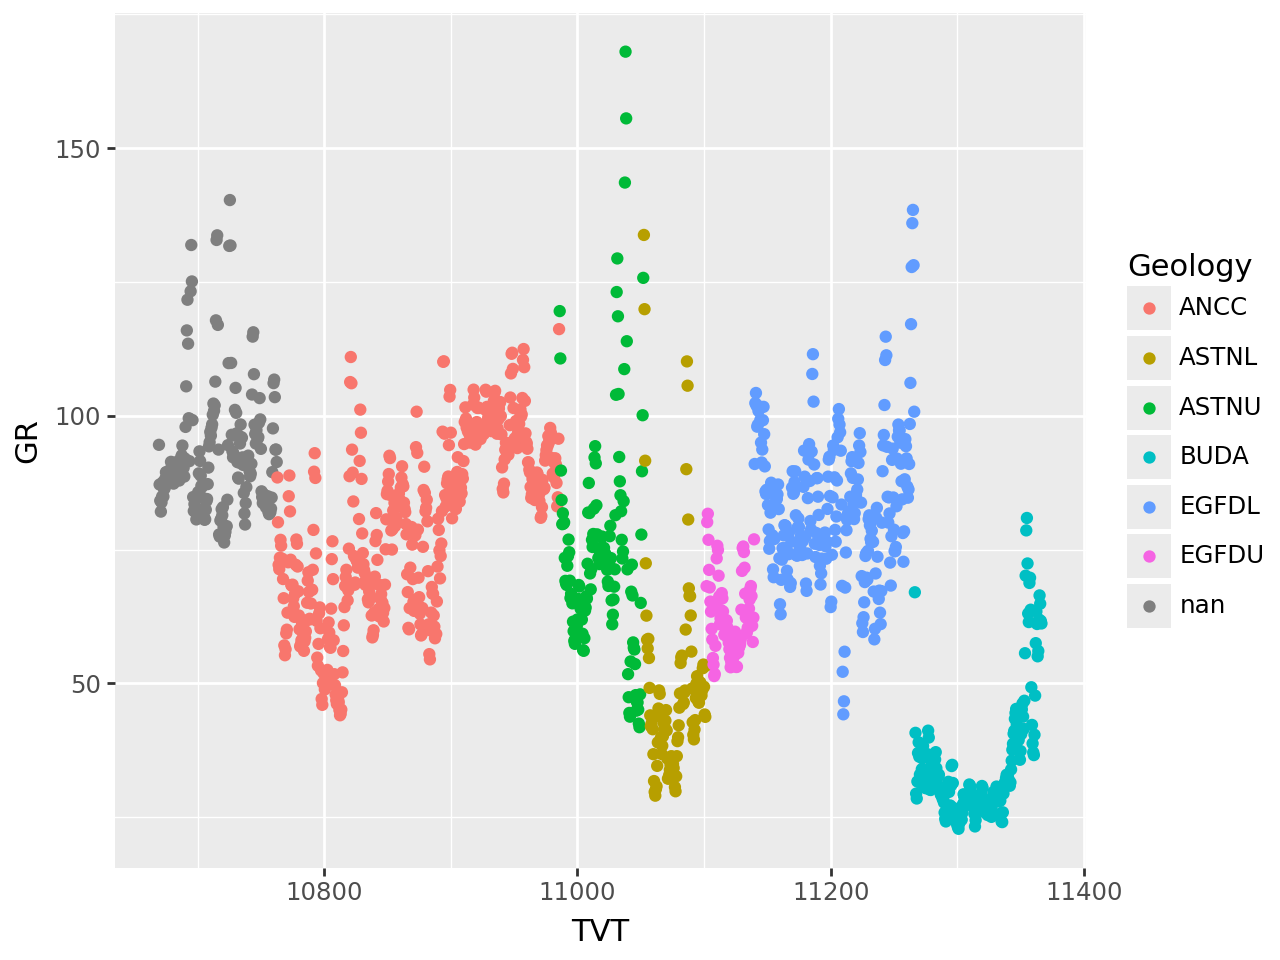

In [27]:
(
    df_t 
    >>
    ggplot() 
    + geom_point(aes(x='TVT',y='GR', color='Geology'))
)

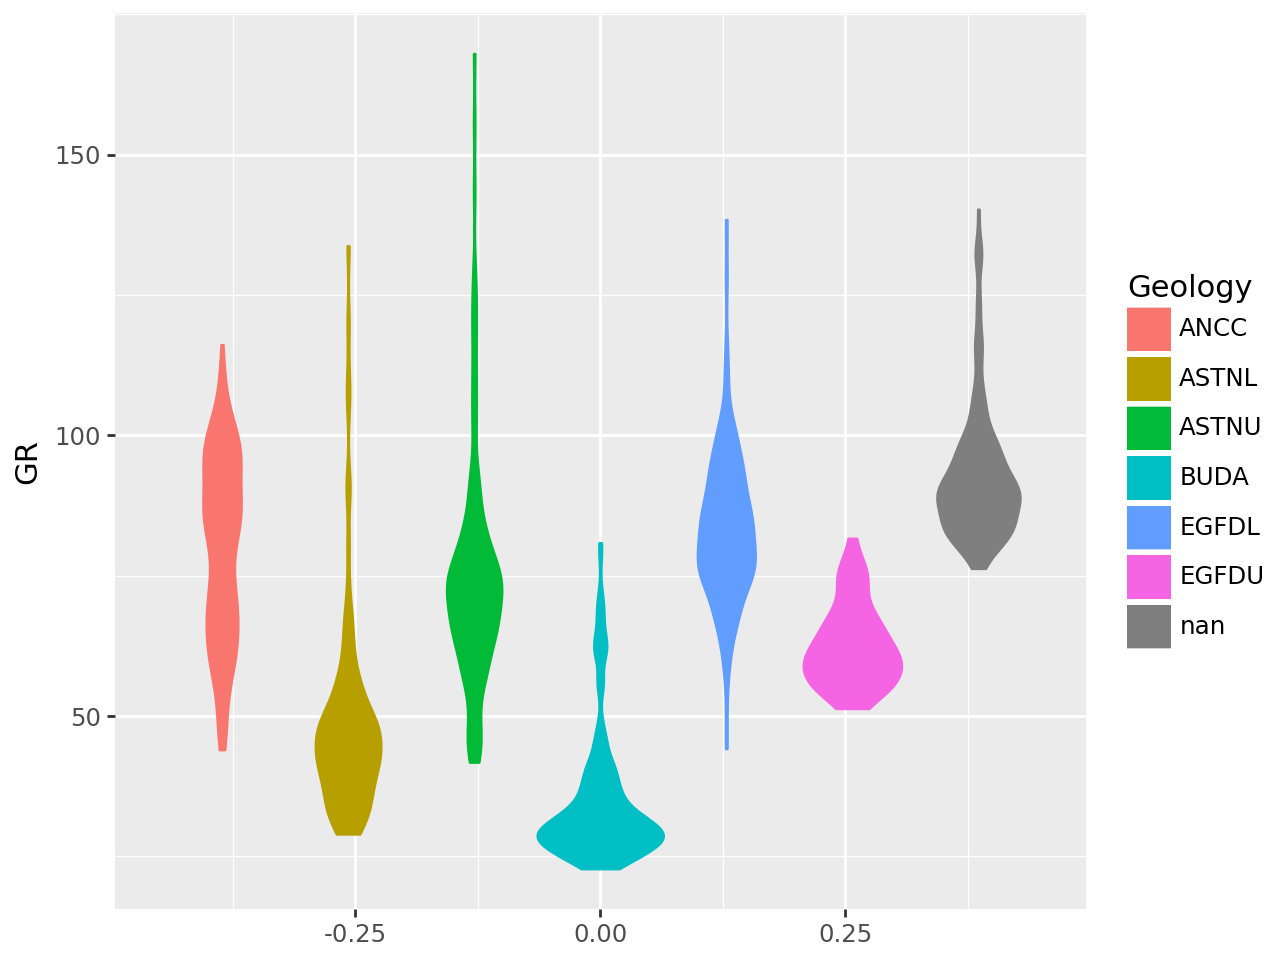

In [28]:
(
    df_t 
    >>
    ggplot() 
    + geom_violin(aes(y='GR', color='Geology', fill='Geology'))
)

In [29]:
df_ht = pd.read_csv('Data/test/00bbac68__horizontal_well.csv')
df_tt = pd.read_csv('Data/test/00bbac68__typewell.csv')

In [30]:
df_ht

,MD,X,Y,Z,GR,TVT_input
0,11578.0,3010760.08,1084504.51,-9436.36,99.123575,11406.63
1,11579.0,3010760.08,1084504.50,-9437.36,100.422528,11407.67
2,11580.0,3010760.08,1084504.49,-9438.36,102.602380,11408.71
3,11581.0,3010760.08,1084504.48,-9439.36,NaN,11409.75
4,11582.0,3010760.08,1084504.47,-9440.36,93.435055,11410.78
...,...,...,...,...,...,...
7554,19132.0,3005792.08,1089518.64,-9996.34,113.845045,NaN
7555,19133.0,3005791.35,1089519.32,-9996.34,123.729035,NaN
7556,19134.0,3005790.61,1089520.00,-9996.34,131.224145,NaN
7557,19135.0,3005789.88,1089520.68,-9996.34,128.894987,NaN


In [31]:
df_tt

,TVT,GR
0,11394.45,95.60
1,11394.95,96.28
2,11395.45,96.72
3,11395.95,97.55
4,11396.45,97.92
...,...,...
1941,12364.95,40.02
1942,12365.45,40.61
1943,12365.95,40.70
1944,12366.45,40.35
